# Sprint 2 et 3 — Notebook final : Pipeline d'indexation hybride : Vecteurs + Graphe de connaissances 

**PFE :** Agentic GraphRAG | **Étudiante :** Wiame Anejjar | **Encadrant :** Pr. Abdelaaziz Hessane


Ce notebook est la **version finale** et contient :
- Logging JSON strict `{entities:[], relations:[]}` + **taux de parsing**
- Fix warnings LightRAG (`complete delimiter` manquant, relations 4/5 champs) via `sanitize_extraction_output()`
- Évaluation quantitative : **latence**, **RAGAS faithfulness**, **nodes traversed approx**
- Export Neo4j fiable depuis **GraphML** (import batch)
- **LLM local uniquement** (Ollama), **pas Groq**


## 0) Installation (une seule fois)

### 0.1 — Nettoyage des dépendances

Ce script prépare l'environnement en supprimant les packages conflictuels qui peuvent causer des erreurs d'importation lors de l'utilisation de RAGAS et LangChain. Cette étape garantit que les dépendances ultérieures s'installent correctement sans conflit de versioning.

In [20]:
import subprocess, sys

pkgs = [
    "ragas",
    "langchain",
    "langchain-core",
    "langchain-community",
    "langchain-text-splitters",
    "langsmith",
    "openai"
]

for p in pkgs:
    subprocess.run(
        [sys.executable, "-m", "pip", "uninstall", "-y", p]
    )

print("Nettoyage terminé")

Nettoyage terminé


### 0.2 — Vérification de l'import RAGAS et LangChain

Validation que les packages critiques (RAGAS, LangChain, embeddings Ollama) sont correctement installés et importables. Cette vérification préalable évite les erreurs durant l'exécution des cellules ultérieures.

In [1]:
from ragas import evaluate

from ragas.metrics import (
    faithfulness,
    answer_relevancy,
    context_precision,
    context_recall
)

from langchain_community.chat_models import ChatOllama

print("OK")

c:\Users\ADMIN\Desktop\PFE_Agentic_Graphrag\GraphRag_PFE\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


OK


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_23352\3722685968.py:3: DeprecationWarning: Importing faithfulness from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import faithfulness
  from ragas.metrics import (
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_23352\3722685968.py:3: DeprecationWarning: Importing answer_relevancy from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import answer_relevancy
  from ragas.metrics import (
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_23352\3722685968.py:3: DeprecationWarning: Importing context_precision from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import context_precision
  from ragas.metrics import (
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_23

## 1) Configuration (LOCAL Ollama)

### 1.1 — Configuration des chemins et variables d'environnement

Initialisation complète de l'environnement du projet : chemins des répertoires (data, indexes, output), paramètres Ollama (URL, modèle, dimension embedding), paramètres LightRAG (taille chunks, gleaning, tokens max), et configuration Neo4j. Cette centralisation des paramètres facilite les ajustements futurs.

In [11]:
import os, json, time, shutil, asyncio, requests
from pathlib import Path
from dataclasses import dataclass, field
from typing import Any

import numpy as np
from dotenv import load_dotenv
from tqdm import tqdm
import nest_asyncio
nest_asyncio.apply()
load_dotenv()

BASE_DIR = Path('.')
DATA_DIR = BASE_DIR / 'data' / 'processed'
INDEX_DIR = BASE_DIR / 'indexes' / 'lightrag_500_connected_v2'
OUT_DIR = DATA_DIR / 'triplets'
OUT_DIR.mkdir(parents=True, exist_ok=True)
INDEX_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT = DATA_DIR / 'checkpoint_500_connected_v2.json'

OLLAMA_URL = os.getenv('OLLAMA_URL', 'http://localhost:11434').strip().rstrip('/')
MODEL_NAME = os.getenv('MODEL_NAME', 'llama3.1:8b').strip()
EMBED_MODEL = os.getenv('EMBED_MODEL', 'nomic-embed-text').strip()
EMBED_DIM = int(os.getenv('EMBED_DIM', '768'))

NEO4J_URI = os.getenv('NEO4J_URI', '').strip()
NEO4J_USER = os.getenv('NEO4J_USER', os.getenv('NEO4J_USERNAME','neo4j')).strip()
NEO4J_PASSWORD = os.getenv('NEO4J_PASSWORD', '').strip()

NB_DOCS = int(os.getenv('NB_DOCS', '500'))

# Reglages stabilite + densite
CHUNK_TOKEN_SIZE = int(os.getenv('CHUNK_TOKEN_SIZE', '700'))
CHUNK_OVERLAP = int(os.getenv('CHUNK_OVERLAP', '120'))
MAX_EXTRACT_INPUT_TOKENS = int(os.getenv('MAX_EXTRACT_INPUT_TOKENS', '6000'))

ENTITY_EXTRACT_MAX_GLEANING = int(os.getenv('ENTITY_EXTRACT_MAX_GLEANING', '6'))
MAX_TOKENS_EXTRACT = int(os.getenv('MAX_TOKENS_EXTRACT', '1800'))
MAX_TOKENS_QUERY = int(os.getenv('MAX_TOKENS_QUERY', '900'))
OLLAMA_NUM_CTX = int(os.getenv('OLLAMA_NUM_CTX', '8192'))
LLM_MAX_ASYNC = int(os.getenv('LLM_MAX_ASYNC', '1'))
MAX_PARALLEL_INSERT = int(os.getenv('MAX_PARALLEL_INSERT', '1'))
SLEEP_BETWEEN_DOCS_S = float(os.getenv('SLEEP_BETWEEN_DOCS_S', '0.2'))

print('Config:')
print(' INDEX_DIR=', INDEX_DIR)
print(' NB_DOCS=', NB_DOCS)
print(' OLLAMA MODEL_NAME=', MODEL_NAME)
print(' EMBED_MODEL=', EMBED_MODEL, 'dim=', EMBED_DIM)
print(' gleaning=', ENTITY_EXTRACT_MAX_GLEANING)
print(' chunk_token_size=', CHUNK_TOKEN_SIZE, 'overlap=', CHUNK_OVERLAP)
print(' MAX_EXTRACT_INPUT_TOKENS=', MAX_EXTRACT_INPUT_TOKENS)
print(' MAX_TOKENS_EXTRACT=', MAX_TOKENS_EXTRACT)
print(' OLLAMA_NUM_CTX=', OLLAMA_NUM_CTX)


Config:
 INDEX_DIR= indexes\lightrag_500_connected_v2
 NB_DOCS= 500
 OLLAMA MODEL_NAME= llama3.1:8b
 EMBED_MODEL= nomic-embed-text dim= 768
 gleaning= 6
 chunk_token_size= 700 overlap= 120
 MAX_EXTRACT_INPUT_TOKENS= 6000
 MAX_TOKENS_EXTRACT= 1800
 OLLAMA_NUM_CTX= 8192


## 2) Logger JSON strict + taux de parsing (métrique qualité)

### 2.1 — Classe TripletLogger et système de parsing JSON strict

Implémentation d'un logger personnalisé qui enregistre les résultats de l'extraction LLM en format JSON structuré `{entities:[], relations:[]}`. Inclut le parsing strict avec métriques de qualité (taux de parsing, délimiteurs manquants, lignes malformées). Cette classe garantit la traçabilité complète de l'extraction et permet l'audit qualité ultérieur.

In [12]:
try:
    from lightrag.prompt import PROMPTS
    TUPLE_DELIM = PROMPTS.get('DEFAULT_TUPLE_DELIMITER', '<|#|>')
    COMPLETE_DELIM = PROMPTS.get('DEFAULT_COMPLETION_DELIMITER', '<|COMPLETE|>')

    # Graph quality rules: fewer duplicate nodes, more useful cross-document relations.
    PROMPTS['entity_extraction_system_prompt'] += """
---Additional Graph Quality Rules---
Extract reusable scientific entities, not full paper titles.
Do not extract the complete document title as an entity unless it is a named model, dataset, benchmark, tool, or method.

Use canonical names consistently:
- LLM, LLMs, Large Language Model, Large Language Models -> Large Language Models
- VLM, VLMs, Vision-Language Model(s) -> Vision-Language Models
- GNN, GNNs, Graph Neural Network(s) -> Graph Neural Networks
- RAG, Retrieval Augmented Generation -> Retrieval-Augmented Generation

Avoid isolated entities. Every extracted entity should participate in at least one relationship.
Prefer fewer high-quality entities over many weak entities.
For each chunk, extract as many meaningful relationships as possible between methods, models, datasets, tasks, metrics, benchmarks, applications, and concepts.
Use specific predicates such as uses, improves, evaluates_on, trained_on, applied_to, part_of, based_on, compares_with, extends, addresses.
Avoid generic predicates like related_to.
"""
except Exception:
    TUPLE_DELIM = '<|#|>'
    COMPLETE_DELIM = '<|COMPLETE|>'

@dataclass
class TripletLogger:
    total_llm_calls: int = 0
    parse_success: int = 0
    parse_failed: int = 0
    missing_complete_delimiter: int = 0
    malformed_entity_lines: int = 0
    malformed_relation_lines: int = 0
    total_entities: int = 0
    total_relations: int = 0
    items: list[dict[str, Any]] = field(default_factory=list)

    def parse_extraction(self, text: str, doc_id: str | None = None) -> dict[str, Any]:
        self.total_llm_calls += 1
        if COMPLETE_DELIM not in text:
            self.missing_complete_delimiter += 1

        entities, relations = [], []
        raw_lines = [ln.strip() for ln in text.splitlines() if ln.strip()]
        try:
            for ln in raw_lines:
                if ln == COMPLETE_DELIM:
                    break
                parts = ln.split(TUPLE_DELIM)
                if not parts:
                    continue

                if parts[0] == 'entity':
                    if len(parts) < 4:
                        self.malformed_entity_lines += 1
                        continue
                    entities.append({'name': parts[1].strip(), 'type': parts[2].strip(), 'description': parts[3].strip()})

                elif parts[0] == 'relation':
                    if len(parts) == 4:
                        self.malformed_relation_lines += 1
                        parts = parts + ['']
                    if len(parts) < 5:
                        self.malformed_relation_lines += 1
                        continue
                    relations.append({
                        'source': parts[1].strip(),
                        'target': parts[2].strip(),
                        'relation_keywords': parts[3].strip(),
                        'description': parts[4].strip(),
                    })

            self.parse_success += 1
            self.total_entities += len(entities)
            self.total_relations += len(relations)
            payload = {'doc_id': doc_id, 'entities': entities, 'relations': relations}
            self.items.append(payload)
            return payload
        except Exception:
            self.parse_failed += 1
            payload = {'doc_id': doc_id, 'entities': [], 'relations': [], 'raw': text[:400]}
            self.items.append(payload)
            return payload

    def save(self, path: Path):
        meta = {
            'total_llm_calls': self.total_llm_calls,
            'parse_success': self.parse_success,
            'parse_failed': self.parse_failed,
            'parse_success_pct': round(self.parse_success / max(1, self.total_llm_calls) * 100, 2),
            'missing_complete_delimiter': self.missing_complete_delimiter,
            'malformed_entity_lines': self.malformed_entity_lines,
            'malformed_relation_lines': self.malformed_relation_lines,
            'total_entities': self.total_entities,
            'total_relations': self.total_relations,
            'tuple_delimiter': TUPLE_DELIM,
            'completion_delimiter': COMPLETE_DELIM,
        }
        with open(path, 'w', encoding='utf-8') as f:
            json.dump({'metadata': meta, 'triplets': self.items}, f, ensure_ascii=False, indent=2)
        print('Saved:', path)

triplet_logger = TripletLogger()
print('Delimiters:', TUPLE_DELIM, COMPLETE_DELIM)


Delimiters: <|#|> <|COMPLETE|>


## 3) LLM local + fix warnings (`sanitize_extraction_output`)

### 3.1 — LLM local Ollama + fonctions de sanitization

Définition des deux fonctions critiques :
1. **`local_llm_func()`** : Appelle le LLM Ollama en local via endpoint `/api/chat`, avec support des extractions structurées (détection via system prompt) et sanitization automatique
2. **`embedding_func()`** : Génère les embeddings via Ollama `/api/embeddings` (nomic-embed-text, 768 dims)
3. **`sanitize_extraction_output()`** : Nettoie les triplets LLM en supprimant les entités mauvaises, validant les relations, et normalisant les noms (canonicalization)
4. **`canonicalize_entity_name()`** : Standardise les noms d'entités (ex: "LLM" → "Large Language Models")

Ces fonctions assurent la qualité des extractions et réduisent les hallucinations du LLM.

In [13]:
CURRENT_DOC_ID = None

def is_extraction_call(system_prompt):
    if not system_prompt:
        return False
    sp = system_prompt.lower()
    return ('knowledge graph specialist' in sp) or (TUPLE_DELIM in system_prompt)

from pyexpat.errors import messages
import re

from typer import prompt

CANONICAL_ALIASES = {
    "llm": "Large Language Models",
    "llms": "Large Language Models",
    "large language model": "Large Language Models",
    "large language models": "Large Language Models",
    "large language models llms": "Large Language Models",
    "llm large language model": "Large Language Models",
    "vlm": "Vision-Language Models",
    "vlms": "Vision-Language Models",
    "vision language model": "Vision-Language Models",
    "vision language models": "Vision-Language Models",
    "vision language models vlms": "Vision-Language Models",
    "gnn": "Graph Neural Networks",
    "gnns": "Graph Neural Networks",
    "graph neural network": "Graph Neural Networks",
    "graph neural networks": "Graph Neural Networks",
    "rag": "Retrieval-Augmented Generation",
    "retrieval augmented generation": "Retrieval-Augmented Generation",
    "retrieval augmented generation rag": "Retrieval-Augmented Generation",
    "transformer architecture": "Transformer Architecture",
    "kv cache": "KV Cache",
    "kv-cache": "KV Cache",
    "gpt 5 mini": "GPT-5-Mini",
    "gpt-5-mini": "GPT-5-Mini",
    "gpt 5 4": "GPT-5.4",
    "gpt-5.4": "GPT-5.4",
    "question answering qa": "Question Answering",
    "llm as a judge": "LLM-as-a-Judge",
    "llm-as-a-judge": "LLM-as-a-Judge",
    "large language model llm": "Large Language Models",
    "large language model s": "Large Language Models",
    "llm large language models": "Large Language Models",
    "vision language model vlm": "Vision-Language Models",
    "graph neural network gnn": "Graph Neural Networks",
    "artificial intelligence ai": "Artificial Intelligence",
    "natural language processing nlp": "Natural Language Processing",
}

BAD_ENTITY_NAMES = {
    "model", "models", "method", "methods", "dataset", "datasets",
    "task", "tasks", "metric", "metrics", "paper", "study",
    "approach", "system", "framework", "technique", "result", "results"
}

PROTECTED_ACRONYMS = {
    "AI", "ML", "NLP", "LLM", "VLM", "GNN", "RAG", "GPT", "BERT", "T5",
    "CNN", "RNN", "LSTM", "PPO", "SFT", "RLHF", "DPO", "GQA", "MLA", "KV"
}

def normalize_key(name: str) -> str:
    return re.sub(r"[^a-z0-9]+", " ", str(name or "").lower()).strip()

def canonicalize_entity_name(name: str) -> str:
    s = str(name or "").strip().strip("\"'`")
    s = re.sub(r"\\+", "", s)
    s = re.sub(r"\s+", " ", s)
    s = re.sub(r"\s*[-??]\s*", "-", s)
    key = normalize_key(s)

    if key in CANONICAL_ALIASES:
        return CANONICAL_ALIASES[key]

    if re.search(r"\b(GPT|LLM|VLM|GNN|RAG|BERT|T5|AI|ML|NLP|CNN|RNN|LSTM|RLHF|DPO)\b", s, re.I):
        return s

    if s.upper() in PROTECTED_ACRONYMS:
        return s.upper()

    return s.title()

def is_bad_entity(name: str) -> bool:
    key = normalize_key(name)
    words = re.findall(r"[A-Za-z0-9]+", name)

    if key in BAD_ENTITY_NAMES:
        return True

    # Full paper titles create one-node-per-paper fragments. Keep long names only if they look like reusable artifacts.
    if len(words) > 14:
        keep_terms = ["model", "dataset", "benchmark", "architecture", "framework", "algorithm", "tool", "corpus"]
        if not any(t in key for t in keep_terms):
            return True

    return False

def sanitize_extraction_output(text):
    lines = [ln.strip() for ln in (text or "").splitlines() if ln.strip()]
    entities = {}
    relations = []

    for ln in lines:
        if ln == COMPLETE_DELIM:
            break

        parts = ln.split(TUPLE_DELIM)
        if not parts:
            continue

        if parts[0] == "entity":
            if len(parts) == 3:
                parts = parts + [""]
            if len(parts) < 4:
                continue

            name = canonicalize_entity_name(parts[1])
            if is_bad_entity(name):
                continue

            ent_type = parts[2].strip() or "Concept"
            desc = parts[3].strip()
            entities[name] = (ent_type, desc)

        elif parts[0] == "relation":
            if len(parts) == 4:
                parts = parts + [""]
            if len(parts) < 5:
                continue

            src = canonicalize_entity_name(parts[1])
            tgt = canonicalize_entity_name(parts[2])

            if src == tgt or is_bad_entity(src) or is_bad_entity(tgt):
                continue

            pred = parts[3].strip() or "associated_with"
            desc = parts[4].strip()
            relations.append((src, tgt, pred, desc))

    used_entities = {s for s, _, _, _ in relations} | {t for _, t, _, _ in relations}

    fixed = []
    for name in sorted(used_entities):
        ent_type, desc = entities.get(
            name,
            ("Concept", f"{name} is mentioned in a relation extracted from the chunk."),
        )
        fixed.append(f"entity{TUPLE_DELIM}{name}{TUPLE_DELIM}{ent_type}{TUPLE_DELIM}{desc}")

    seen_rel = set()
    for src, tgt, pred, desc in relations:
        key = tuple(sorted([src, tgt])) + (pred.lower(),)
        if key in seen_rel:
            continue
        seen_rel.add(key)
        fixed.append(f"relation{TUPLE_DELIM}{src}{TUPLE_DELIM}{tgt}{TUPLE_DELIM}{pred}{TUPLE_DELIM}{desc}")

    fixed.append(COMPLETE_DELIM)
    return "\n".join(fixed)


import aiohttp

async def local_llm_func(
    prompt,
    system_prompt=None,
    history_messages=[],
    **kwargs
):
    """
    LLM local via Ollama — endpoint /api/chat uniquement.
    Version asynchrone compatible avec LightRAG 1.4.15
    """
    print("######### LOCAL LLM CALLED #########")
    messages = []

    if system_prompt:
        messages.append({
            'role': 'system',
            'content': system_prompt
        })

    for msg in history_messages:
        messages.append(msg)

    messages.append({
        'role': 'user',
        'content': prompt
    })

    extraction = is_extraction_call(system_prompt)
    num_predict = (
        MAX_TOKENS_EXTRACT
        if extraction
        else MAX_TOKENS_QUERY
    )
    print("\n" + "="*80)
    print("LOCAL_LLM_FUNC")
    print("EXTRACTION =", extraction)
    print("NUM_PREDICT =", num_predict)
    print("PROMPT LEN =", len(prompt))
    print("SYSTEM PROMPT EXISTS =", system_prompt is not None)

    if prompt:
        print("PROMPT START:")
        print(prompt[:500])

    print("="*80 + "\n")

    timeout = aiohttp.ClientTimeout(total=600)

    try:

        async with aiohttp.ClientSession(timeout=timeout) as session:
            print("=" * 80)
            print("NB MESSAGES =", len(messages))
            print("PROMPT LEN =", len(prompt))

            for i, m in enumerate(messages):
                print(f"\nMESSAGE {i}")
                print("ROLE :", m["role"])
                print("LEN  :", len(m["content"]))
                print(m["content"][:300])

            async with session.post(
                f"{OLLAMA_URL}/api/chat",
                json={
                    "model": MODEL_NAME,
                    "messages": messages,
                    "stream": False,
                    "options": {
                        "temperature": 0,
                        "num_predict": num_predict,
                        "num_ctx": OLLAMA_NUM_CTX,
                    },
                },
            ) as response:

                response.raise_for_status()
                data = await response.json()

        out = data.get("message", {}).get("content", "") or ""
        print("OUTPUT LEN =", len(out))
        print("OUTPUT START =", repr(out[:200]))

    except aiohttp.ClientConnectionError:
        print("Ollama inaccessible — lance : ollama serve")
        raise

    except aiohttp.ClientResponseError as e:
        print(f"Erreur HTTP Ollama : {e}")
        raise

    # Logger les triplets si extraction
    if extraction:
        out = sanitize_extraction_output(out)
        triplet_logger.parse_extraction(
            out,
            doc_id=CURRENT_DOC_ID
        )

    return out

async def embedding_func(texts):
    """
    Embedding Ollama — endpoint /api/embeddings uniquement.
    Retourne numpy 2D (n_textes, EMBED_DIM).
    """
    embs = []
    for t in texts:
        r = requests.post(
            f'{OLLAMA_URL}/api/embeddings',
            json={'model': EMBED_MODEL, 'prompt': t},
            timeout=300,
        )
        r.raise_for_status()
        emb = r.json().get('embedding', [])
        embs.append(np.array(emb, dtype=np.float32))
    return np.vstack(embs)


print(' LLM local défini — endpoint /api/chat uniquement')
print(f'   Ollama URL  : {OLLAMA_URL}')
print(f'   Modèle LLM  : {MODEL_NAME}')
print(f'   Embedding   : {EMBED_MODEL} ({EMBED_DIM} dim)')

 LLM local défini — endpoint /api/chat uniquement
   Ollama URL  : http://localhost:11434
   Modèle LLM  : llama3.1:8b
   Embedding   : nomic-embed-text (768 dim)


In [4]:
# Voir ce qu'il y a vraiment dans kv_store_full_relations.json
with open(INDEX_DIR / "kv_store_full_relations.json", encoding="utf-8") as f:
    rels = json.load(f)

# Afficher la valeur d'une clé
first_key = list(rels.keys())[0]
print(f"Clé : {first_key}")
print(f"Valeur : {json.dumps(rels[first_key], indent=2, ensure_ascii=False)[:500]}")

Clé : Adaptive Programming PracticePersonalized Worked Example Generation From Student Code Submissions Using Pattern-Based Knowledge Components
Valeur : {
  "src_id": "Adaptive Programming Practice",
  "tgt_id": "Personalized Worked Example Generation From Student Code Submissions Using Pattern-Based Knowledge Components",
  "weight": 1.0,
  "description": "Adaptive Programming Practice\nPersonalized Worked Example Generation From Student Code Submissions Using Pattern-Based Knowledge Components\nThis concept is applied in the context of adaptive programming practice for generating personalized worked examples.",
  "keywords": "concept applicati


### 3.2 — Test de connectivité Ollama

Vérification que le serveur Ollama est accessible et répond correctement à une requête simple. Ce test diagnostique précoce prévient les blocages lors de l'indexation complète.

In [4]:
import requests
import json

print('Test /api/chat...')

payload = {
    'model': MODEL_NAME,
    'messages': [
        {'role': 'user', 'content': 'Say only: OK'}
    ],
    'stream': False,
    'options': {
        'temperature': 0,
        'num_predict': 8,
        'num_ctx': 2048,
    },
}

try:
    r = requests.post(
        f'{OLLAMA_URL}/api/chat',
        json=payload,
        timeout=600,
    )
    r.raise_for_status()
    data = r.json()
    print('STATUS:', r.status_code)
    print('MESSAGE:', data.get('message', {}).get('content', data))
except requests.exceptions.ReadTimeout as e:
    raise TimeoutError(
        'Ollama a depasse 600s. Verifie que ollama serve est lance, que le modele est deja pull, et que le PC n est pas sature.'
    ) from e


Test /api/chat...
STATUS: 200
MESSAGE: OK


## 4) Indexation 500 docs + checkpoint

### 4.1 — Indexation complète du corpus (500 documents)

Pipeline d'indexation LightRAG avec support du checkpointing pour reprendre après interruption. Étapes :
1. Initialisation du RAG avec embeddings Ollama
2. Lecture du corpus arXiv (500 documents)
3. Insertion progressive avec logging des erreurs
4. Sauvegarde du checkpoint après chaque document
5. Export des triplets extraits en JSON

Durée estimée : 3-4 jours selon la puissance du LLM local.

In [14]:
from lightrag import LightRAG, QueryParam
from lightrag.utils import EmbeddingFunc

def load_checkpoint(path: Path):
    if path.exists():
        with open(path, 'r', encoding='utf-8') as f:
            return json.load(f)
    return {'last_index': 0, 'success': 0, 'errors': []}

def save_checkpoint(path: Path, state: dict):
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, 'w', encoding='utf-8') as f:
        json.dump(state, f, ensure_ascii=False, indent=2)

async def build_rag(working_dir: Path) -> LightRAG:
    embed = EmbeddingFunc(
        embedding_dim=EMBED_DIM,
        max_token_size=8192,
        model_name=EMBED_MODEL,
        func=embedding_func,
    )
    rag = LightRAG(
        working_dir=str(working_dir),
        llm_model_func=local_llm_func,
        embedding_func=embed,
        llm_model_max_async=LLM_MAX_ASYNC,
        max_parallel_insert=MAX_PARALLEL_INSERT,
        max_extract_input_tokens=MAX_EXTRACT_INPUT_TOKENS,
        entity_extract_max_gleaning=ENTITY_EXTRACT_MAX_GLEANING,
        chunk_token_size=CHUNK_TOKEN_SIZE,
        chunk_overlap_token_size=CHUNK_OVERLAP,
        addon_params={
            'language': 'English',
            'entity_types': [
                'Model', 'Method', 'Dataset', 'Task', 'Metric',
                'Benchmark', 'Architecture', 'Application',
                'Concept', 'Tool', 'Organization'
            ]
        }
    )
    await rag.initialize_storages()
    return rag

async def index_corpus():
    global CURRENT_DOC_ID, triplet_logger
    reset = input(f"Supprimer l'index {INDEX_DIR} et recommencer ? (o/N): ").strip().lower() == 'o'
    if reset:
        if INDEX_DIR.exists():
            shutil.rmtree(INDEX_DIR)
        if CHECKPOINT.exists():
            CHECKPOINT.unlink()
        INDEX_DIR.mkdir(parents=True, exist_ok=True)
        triplet_logger = TripletLogger()

    rag = await build_rag(INDEX_DIR)

    corpus_path = DATA_DIR / 'arxiv_cleaned.json'
    with open(corpus_path, 'r', encoding='utf-8') as f:
        docs_all = json.load(f)
    docs = docs_all[:NB_DOCS]

    state = load_checkpoint(CHECKPOINT)
    start = state['last_index']
    success = state['success']
    errors = state['errors']

    print(f'Start indexation @ {start} / {len(docs)}')

    for i in tqdm(range(start, len(docs)), desc='Indexation'):
        d = docs[i]
        doc_id = d.get('id', str(i))
        text = d.get('text') or f"Title: {d.get('title','')}\n\nAbstract: {d.get('abstract','')}"
        CURRENT_DOC_ID = doc_id
        try:
            await rag.ainsert(text, ids=doc_id, file_paths=doc_id)
            success += 1
        except Exception as e:
            errors.append({'index': i, 'doc_id': doc_id, 'error': str(e)[:300]})
            await asyncio.sleep(2)
        finally:
            save_checkpoint(CHECKPOINT, {'last_index': i + 1, 'success': success, 'errors': errors})
        await asyncio.sleep(SLEEP_BETWEEN_DOCS_S)

    print('DONE. success=', success, 'errors=', len(errors))
    out_path = OUT_DIR / 'triplets_extraction_llm_500_NV.json'
    if triplet_logger.items:
        triplet_logger.save(out_path)
    else:
        print("Aucun nouveau triplet logg?: je n'ecrase pas", out_path)
    return rag

rag = asyncio.run(index_corpus())


INFO: [] Loaded graph from indexes\lightrag_500_connected_v2\graph_chunk_entity_relation.graphml with 5065 nodes, 5068 edges
INFO:nano-vectordb:Load (5065, 768) data
INFO:nano-vectordb:Init {'embedding_dim': 768, 'metric': 'cosine', 'storage_file': 'indexes\\lightrag_500_connected_v2\\vdb_entities.json'} 5065 data
INFO:nano-vectordb:Load (5068, 768) data
INFO:nano-vectordb:Init {'embedding_dim': 768, 'metric': 'cosine', 'storage_file': 'indexes\\lightrag_500_connected_v2\\vdb_relationships.json'} 5068 data
INFO:nano-vectordb:Load (500, 768) data
INFO:nano-vectordb:Init {'embedding_dim': 768, 'metric': 'cosine', 'storage_file': 'indexes\\lightrag_500_connected_v2\\vdb_chunks.json'} 500 data
INFO: [] Process 28624 KV load full_docs with 500 records
INFO: [] Process 28624 KV load text_chunks with 500 records
INFO: [] Process 28624 KV load full_entities with 500 records
INFO: [] Process 28624 KV load full_relations with 5068 records
INFO: [] Process 28624 KV load entity_chunks with 5065 re

Start indexation @ 500 / 500


Indexation: 0it [00:00, ?it/s]

DONE. success= 499 errors= 0
Aucun nouveau triplet logg?: je n'ecrase pas data\processed\triplets\triplets_extraction_llm_500_NV.json


In [15]:
type(rag)


lightrag.lightrag.LightRAG

### Test et diagnostice de graphe

In [7]:
import json
from pathlib import Path

# Charger vdb_relationships
with open(INDEX_DIR / "vdb_relationships.json", encoding="utf-8") as f:
    vdb_rels = json.load(f)

# Reconstruire kv_store_full_relations au bon format
new_rels = {}

for rel in vdb_rels["data"]:
    src = rel.get("src_id", "")
    tgt = rel.get("tgt_id", "")
    
    # Clé au format attendu par LightRAG
    key = f"{src}{tgt}"
    
    # Parser le content pour extraire keywords et description
    content = rel.get("content", "")
    parts = content.split("\t") if "\t" in content else ["", content]
    keywords = parts[0].strip() if len(parts) > 1 else ""
    description = parts[1].strip() if len(parts) > 1 else content
    
    new_rels[key] = {
        "src_id": src,
        "tgt_id": tgt,
        "weight": 1.0,
        "description": description,
        "keywords": keywords,
        "source_id": rel.get("source_id", ""),
        "file_path": rel.get("file_path", ""),
        "created_at": rel.get("__created_at__", 0),
    }

print(f"Relations reconstruites : {len(new_rels)}")

# Backup d'abord
import shutil
shutil.copy(
    INDEX_DIR / "kv_store_full_relations.json",
    INDEX_DIR / "kv_store_full_relations_BACKUP.json"
)

# Sauvegarder
with open(INDEX_DIR / "kv_store_full_relations.json", "w", encoding="utf-8") as f:
    json.dump(new_rels, f, ensure_ascii=False, indent=2)

print("kv_store_full_relations.json reconstruit ✓")

# Vérification rapide
print("\nExemple de clé reconstruite :")
first = list(new_rels.keys())[0]
print(f"  Clé : {first}")
print(f"  src : {new_rels[first]['src_id']}")
print(f"  tgt : {new_rels[first]['tgt_id']}")

Relations reconstruites : 5068
kv_store_full_relations.json reconstruit ✓

Exemple de clé reconstruite :
  Clé : Adaptive Programming PracticePersonalized Worked Example Generation From Student Code Submissions Using Pattern-Based Knowledge Components
  src : Adaptive Programming Practice
  tgt : Personalized Worked Example Generation From Student Code Submissions Using Pattern-Based Knowledge Components


#### Application de post-traitement pour corriger TOUTE la canonisation du graphe
 - Ici même si le cde montre que c'est une erreur mais c'est juste parce sue j'ai reruner le code car je l'ai déjà exécuté pour la 1ére foid 

In [8]:
import json, re, shutil

# ── Backup ────────────────────────────────────────────────────
for fname in ["vdb_entities.json", "vdb_relationships.json", 
              "kv_store_full_relations.json",
              "graph_chunk_entity_relation.graphml",
              "graph_chunk_entity_relation_merged.graphml"]:
    src = INDEX_DIR / fname
    if src.exists():
        shutil.copy(src, INDEX_DIR / f"{fname}.backup")
print("Backups créés ")

# ── Construire le mapping ─────────────────────────────────────
with open(INDEX_DIR / "vdb_entities.json", encoding="utf-8") as f:
    vdb = json.load(f)

name_map = {}
for entry in vdb["data"]:
    old = entry.get("entity_name", "")
    new = fix_entity_name(old)
    if old != new:
        name_map[old] = new

print(f"Entités à corriger : {len(name_map)}")

def replace_all(text: str) -> str:
    for old, new in name_map.items():
        text = text.replace(old, new)
    return text

# ── 1. vdb_entities.json ──────────────────────────────────────
for entry in vdb["data"]:
    old = entry.get("entity_name", "")
    if old in name_map:
        entry["entity_name"] = name_map[old]
        entry["content"] = replace_all(entry.get("content", ""))

with open(INDEX_DIR / "vdb_entities.json", "w", encoding="utf-8") as f:
    json.dump(vdb, f, ensure_ascii=False, indent=2)
print("vdb_entities.json ")

# ── 2. vdb_relationships.json ─────────────────────────────────
with open(INDEX_DIR / "vdb_relationships.json", encoding="utf-8") as f:
    vdb_rels = json.load(f)

for entry in vdb_rels["data"]:
    for field in ["src_id", "tgt_id", "content"]:
        if field in entry:
            entry[field] = replace_all(entry[field])

with open(INDEX_DIR / "vdb_relationships.json", "w", encoding="utf-8") as f:
    json.dump(vdb_rels, f, ensure_ascii=False, indent=2)
print("vdb_relationships.json ")

# ── 3. kv_store_full_relations.json ───────────────────────────
with open(INDEX_DIR / "kv_store_full_relations.json", encoding="utf-8") as f:
    kv_rels = json.load(f)

new_kv_rels = {}
for k, v in kv_rels.items():
    new_k = replace_all(k)
    if isinstance(v, dict):
        for field in ["src_id", "tgt_id", "description", "keywords"]:
            if field in v:
                v[field] = replace_all(v[field])
    new_kv_rels[new_k] = v

with open(INDEX_DIR / "kv_store_full_relations.json", "w", encoding="utf-8") as f:
    json.dump(new_kv_rels, f, ensure_ascii=False, indent=2)
print("kv_store_full_relations.json ")

# ── 4. graphml ────────────────────────────────────────────────
for graphml in ["graph_chunk_entity_relation.graphml",
                "graph_chunk_entity_relation_merged.graphml"]:
    path = INDEX_DIR / graphml
    if path.exists():
        with open(path, encoding="utf-8") as f:
            content = f.read()
        content = replace_all(content)
        with open(path, "w", encoding="utf-8") as f:
            f.write(content)
        print(f"{graphml} ")

# ── Vider le cache ────────────────────────────────────────────
for cache_file in INDEX_DIR.glob("kv_store_llm*"):
    cache_file.unlink()
    print(f"Cache supprimé : {cache_file.name}")

print(f"\nPost-traitement terminé  — {len(name_map)} corrections appliquées")

Backups créés 


NameError: name 'fix_entity_name' is not defined

### Test de validation aprés changement de la fonction async def local_llm_func

In [16]:
from lightrag.prompt import PROMPTS

PROMPTS["rag_response"] = """---Role---
You are a RAG assistant.

---Rules---
1. Use only provided context.
2. If answer is not in context, say so briefly.

---Context---
{context_data}

---Response---
{response_type}
"""
print(" Patch prompt appliqué — placeholders : context_data + response_type uniquement")

 Patch prompt appliqué — placeholders : context_data + response_type uniquement


### Cette cellule est altérnative lorsque j'ai utilisé la fonction de groq

In [ ]:
import subprocess, sys, os, glob

subprocess.run([sys.executable, "-m", "pip", "install", "groq", "-q"], check=False)

from groq import AsyncGroq
from lightrag import LightRAG, QueryParam
from lightrag.utils import EmbeddingFunc

# ── Groq client ───────────────────────────────────────────────
GROQ_API_KEY = os.getenv("GROQ_API_KEY", "")
groq_client = AsyncGroq(api_key=GROQ_API_KEY)

async def groq_llm_func(prompt, system_prompt=None, history_messages=None, **kwargs):
    history_messages = history_messages or []
    messages = []
    if system_prompt:
        messages.append({"role": "system", "content": system_prompt})
    for msg in history_messages:
        if isinstance(msg, dict):
            messages.append(msg)
    messages.append({"role": "user", "content": prompt})

    response = await groq_client.chat.completions.create(
        model="llama-3.3-70b-versatile",
        messages=messages,
        temperature=0.0,
        max_tokens=800,
    )
    content = response.choices[0].message.content or ""
    return content.strip()

# ── Nettoyage du cache LLM uniquement ─────────────────────────
for cache_file in INDEX_DIR.glob("kv_store_llm*"):
    if cache_file.is_file():
        cache_file.unlink()
        print(f"Cache supprimé : {cache_file.name}")

cache_path = INDEX_DIR / "kv_store_llm_response_cache.json"
cache_path.write_text("{}", encoding="utf-8")
print(f"Cache réinitialisé : {cache_path}")

# ── Initialisation LightRAG avec Groq ────────────────────────
rag_groq = LightRAG(
    working_dir=str(INDEX_DIR),
    llm_model_func=groq_llm_func,
    embedding_func=EmbeddingFunc(
        embedding_dim=EMBED_DIM,
        max_token_size=8192,
        model_name=EMBED_MODEL,
        func=embedding_func,
    ),
    max_parallel_insert=1,
    llm_model_max_async=1,
)

await rag_groq.initialize_storages()
print(f"LightRAG initialisé avec : {rag_groq.llm_model_func.__name__}")

# ── Helper de requête stable ─────────────────────────────────
async def ask_lightrag(question: str):
    context = await rag_groq.aquery(
        question,
        param=QueryParam(
            mode="hybrid",
            only_need_context=True,
            top_k=5,
            chunk_top_k=3,
            enable_rerank=False,
        ),
    )

    answer = await rag_groq.aquery(
        question,
        param=QueryParam(
            mode="hybrid",
            top_k=5,
            chunk_top_k=3,
            enable_rerank=False,
        ),
    )
    return context, answer

# ── Test rapide ─────────────────────────────────────────────
questions = [
    "What is GS-Quant? What task does Knowledge Graph Completion address?",
    "How does CF-VLA vision language action policy model work?",
    "What is the Multi-Track Resolution Strategy used for in federated learning?",
    "Which model uses Segment Anything SAM as a spatial grouping prior for H-Sets?",
    "What is the capital of France?",
]

for q in questions:
    print(f"\n{'='*60}\n{q}\n{'='*60}")
    context, answer = await ask_lightrag(q)
    print("\n[CONTEXT]")
    print(context[:3000] if isinstance(context, str) else context)
    print("\n[ANSWER]")
    print(answer)


Cache supprimé : kv_store_llm_response_cache.json
Cache réinitialisé : indexes\lightrag_500_connected_v2\kv_store_llm_response_cache.json


INFO: [] Loaded graph from indexes\lightrag_500_connected_v2\graph_chunk_entity_relation.graphml with 5065 nodes, 5068 edges
INFO:nano-vectordb:Load (5065, 768) data
INFO:nano-vectordb:Init {'embedding_dim': 768, 'metric': 'cosine', 'storage_file': 'indexes\\lightrag_500_connected_v2\\vdb_entities.json'} 5065 data
INFO:nano-vectordb:Load (5068, 768) data
INFO:nano-vectordb:Init {'embedding_dim': 768, 'metric': 'cosine', 'storage_file': 'indexes\\lightrag_500_connected_v2\\vdb_relationships.json'} 5068 data
INFO:nano-vectordb:Load (500, 768) data
INFO:nano-vectordb:Init {'embedding_dim': 768, 'metric': 'cosine', 'storage_file': 'indexes\\lightrag_500_connected_v2\\vdb_chunks.json'} 500 data
INFO: LLM func: 1 new workers initialized (Timeouts: Func: 180s, Worker: 360s, Health Check: 375s)


LightRAG initialisé avec : wait_func

What is GS-Quant? What task does Knowledge Graph Completion address?


INFO:  == LLM cache == saving: hybrid:keywords:d645b165cfacf5624d0ca44ec3b4660d
INFO: Embedding func: 8 new workers initialized (Timeouts: Func: 30s, Worker: 60s, Health Check: 75s)
INFO: Query nodes: Graph-based algorithms, Entity disambiguation, Relationship extraction, Node classification (top_k:5, cosine:0.2)
INFO: Local query: 5 entites, 11 relations
INFO: Query edges: GS-Quant, Knowledge Graph Completion, Artificial Intelligence (top_k:5, cosine:0.2)
INFO: Global query: 10 entites, 5 relations
INFO: Raw search results: 15 entities, 16 relations, 0 vector chunks
INFO: After truncation: 15 entities, 16 relations
INFO: Selecting 8 from 8 entity-related chunks by vector similarity
INFO: Find no additional relations-related chunks from 16 relations
INFO: Round-robin merged chunks: 8 -> 8 (deduplicated 0)
INFO: Final context: 15 entities, 16 relations, 3 chunks
INFO: Final chunks S+F/O: E2/1 E2/2 E3/3
INFO: Query nodes: Graph-based algorithms, Entity disambiguation, Relationship extrac


[CONTEXT]

Knowledge Graph Data (Entity):

```json
{"entity": "Graph Foundation Models", "type": "concept", "description": "Graph Foundation Models are a type of model used for graph-related tasks such as node classification, link prediction, and graph classification."}
{"entity": "Automated Edge Labeling", "type": "method", "description": "Automated edge labeling turns the graph views into readable knowledge graphs rather than unlabeled layouts."}
{"entity": "Graph Classification", "type": "task", "description": "Graph classification is a task where the entire graph is classified into different categories based on its structure and content."}
{"entity": "Domain-Filtered Knowledge Graphs From Sparse Autoencoder Features", "type": "model", "description": "Domain-Filtered Knowledge Graphs from Sparse Autoencoder Features is a model that constructs domain-specific concept universes from sparse autoencoder features and builds aligned graph views for corpus-level conceptual structure."}
{"

...


[CONTEXT]

Knowledge Graph Data (Entity):

```json
{"entity": "Federated Learning", "type": "concept", "description": "Federated Learning is a machine learning approach that enables multiple clients to collaborate on model training while keeping their data private.<SEP>Federated Learning is a concept that enables collaborative learning among multiple clients while preserving their data privacy.<SEP>Federated learning is an approach to machine learning where multiple clients contribute to the training of a shared model without sharing their local data."}
{"entity": "Fedavg", "type": "method", "description": "FedAvg is an algorithm used in federated learning for model aggregation, which averages gradients element-wise across clients."}
{"entity": "Gradssharding", "type": "model", "description": "GradsSharding is a model for federated learning aggregation on serverless platforms, partitioning gradients into shards for efficient averaging."}
{"entity": "Session Level Context Aggregation A

INFO:  == LLM cache == saving: hybrid:keywords:92294f0bce105eb8d23f848bd090895a
INFO: Query nodes: Segment Anything SAM, Prior models, H-Sets architecture (top_k:5, cosine:0.2)
INFO: Local query: 5 entites, 9 relations
INFO: Query edges: Spatial grouping, H-Sets, Deep learning models (top_k:5, cosine:0.2)
INFO: Global query: 9 entites, 5 relations
INFO: Raw search results: 14 entities, 14 relations, 0 vector chunks
INFO: After truncation: 14 entities, 14 relations
INFO: Selecting 10 from 10 entity-related chunks by vector similarity
INFO: Find no additional relations-related chunks from 14 relations
INFO: Round-robin merged chunks: 10 -> 10 (deduplicated 0)
INFO: Final context: 14 entities, 14 relations, 3 chunks
INFO: Final chunks S+F/O: E1/1 E3/2 E1/3
INFO: Query nodes: Segment Anything SAM, Prior models, H-Sets architecture (top_k:5, cosine:0.2)
INFO: Local query: 5 entites, 9 relations
INFO: Query edges: Spatial grouping, H-Sets, Deep learning models (top_k:5, cosine:0.2)
INFO: Glo


[CONTEXT]

Knowledge Graph Data (Entity):

```json
{"entity": "2.5D U-Net Architecture", "type": "architecture", "description": "The 2.5D U-Net architecture is used for segmenting GME in space-time connected data."}
{"entity": "Deep-Learning (DL) Classifiers", "type": "model", "description": "Deep-learning classifiers are used for diabetic retinopathy grading but lack interpretability in clinical contexts."}
{"entity": "Generative Models", "type": "model", "description": "Generative models are a type of artificial intelligence model that can generate new data or content based on existing patterns and structures."}
{"entity": "From Pixels to Explanations: Interpretable Diabetic Retinopathy Grading with CNN-Transformer Ensembles, Visual Explainability and Vision-Language Models", "type": "concept", "description": "From Pixels to Explanations: Interpretable Diabetic Retinopathy Grading with CNN-Transformer Ensembles, Visual Explainability and Vision-Language Models is mentioned in a rela

INFO:  == LLM cache == saving: hybrid:keywords:8b9548fe5c5613e21e7f2851657ec7c1
INFO: Query nodes: France, Paris (top_k:5, cosine:0.2)
INFO: Local query: 5 entites, 8 relations
INFO: Query edges: Capital city, Geography (top_k:5, cosine:0.2)
INFO: Global query: 9 entites, 5 relations
INFO: Raw search results: 14 entities, 13 relations, 0 vector chunks
INFO: After truncation: 14 entities, 13 relations
INFO: Selecting 6 from 6 entity-related chunks by vector similarity
INFO: Find no additional relations-related chunks from 13 relations
INFO: Round-robin merged chunks: 6 -> 6 (deduplicated 0)
INFO: Final context: 14 entities, 13 relations, 3 chunks
INFO: Final chunks S+F/O: E2/1 E3/2 E2/3
INFO: Query nodes: France, Paris (top_k:5, cosine:0.2)
INFO: Local query: 5 entites, 8 relations
INFO: Query edges: Capital city, Geography (top_k:5, cosine:0.2)
INFO: Global query: 9 entites, 5 relations
INFO: Raw search results: 14 entities, 13 relations, 0 vector chunks
INFO: After truncation: 14 enti


[CONTEXT]

Knowledge Graph Data (Entity):

```json
{"entity": "Lobby", "type": "location", "description": "The lobby is the location where the digital front-desk system was deployed."}
{"entity": "Geographic Knowledge Bases", "type": "concept", "description": "Geographic knowledge bases are minimized by ReaGeo through its end-to-end geocoding framework."}
{"entity": "Hilbert Space", "type": "concept", "description": "The Hilbert space is the vector space used to represent quantum states."}
{"entity": "Reageo", "type": "model", "description": "ReaGeo is a proposed end-to-end geocoding framework based on large language models designed to overcome the limitations of traditional multi-stage approaches."}
{"entity": "Digital Front-Desk System", "type": "application", "description": "The digital front-desk system is an AI-powered interface used in the lobby of the international financial institution."}
{"entity": "Structured Geographic Knowledge Bases", "type": "concept", "description": "St

In [9]:
from neo4j import GraphDatabase
import os
from dotenv import load_dotenv
load_dotenv()

driver = GraphDatabase.driver(
    os.getenv("NEO4J_URI"),
    auth=(os.getenv("NEO4J_USER", "neo4j"), os.getenv("NEO4J_PASSWORD"))
)

with driver.session() as session:
    # Labels de noeuds
    labels = session.run("CALL db.labels()").data()
    print("LABELS:", labels)
    
    # Types de relations
    rel_types = session.run("CALL db.relationshipTypes()").data()
    print("REL_TYPES:", rel_types)
    
    # Exemple de noeud
    sample_node = session.run("MATCH (n) RETURN n LIMIT 1").data()
    print("SAMPLE NODE:", sample_node)
    
    # Exemple de relation
    sample_rel = session.run("MATCH ()-[r]->() RETURN r LIMIT 1").data()
    print("SAMPLE REL:", sample_rel)
    
    # Compter les noeuds
    count = session.run("MATCH (n) RETURN count(n) as c").data()
    print("NODE COUNT:", count)

driver.close()

LABELS: [{'label': 'Entity'}]
REL_TYPES: [{'relationshipType': 'RELATES_TO'}]
SAMPLE NODE: [{'n': {'name': '10 Gb', 'description': '10 GB is a metric representing the per-function memory limit on AWS Lambda.', 'id': '10 Gb', 'type': 'metric'}}]
SAMPLE REL: [{'r': ({}, 'RELATES_TO', {})}]
NODE COUNT: [{'c': 5065}]


In [18]:
await rag_groq.aquery(
    "Which model uses Segment Anything SAM as a spatial grouping prior for H-Sets?",
    QueryParam(
    mode="hybrid",
    top_k=3,
    enable_rerank=False,
)
)

INFO: Query nodes: Segment Anything SAM, Prior models, H-Sets architecture (top_k:3, cosine:0.2)
INFO: Local query: 3 entites, 7 relations
INFO: Query edges: Spatial grouping, H-Sets, Deep learning models (top_k:3, cosine:0.2)
INFO: Global query: 6 entites, 3 relations
INFO: Raw search results: 9 entities, 10 relations, 0 vector chunks
INFO: After truncation: 9 entities, 10 relations
INFO: Selecting 7 from 7 entity-related chunks by vector similarity
INFO: Find no additional relations-related chunks from 10 relations
INFO: Round-robin merged chunks: 7 -> 7 (deduplicated 0)
INFO: Final context: 9 entities, 10 relations, 7 chunks
INFO: Final chunks S+F/O: E2/1 E2/2 E1/3 E1/4 E1/5 E1/6 E2/7
INFO:  == LLM cache == saving: hybrid:query:b9b5e1c79f51cefb21313b4ba55d99cf


'Not in context.'

In [10]:
import os

cache = INDEX_DIR / "kv_store_llm_response_cache.json"

if cache.exists():
    cache.unlink()

with open(cache, "w", encoding="utf8") as f:
    f.write("{}")

print("Cache vidé")

Cache vidé


In [30]:
res = await rag_groq.aquery(
    "GS-Quant",
    QueryParam(mode="local", top_k=5, enable_rerank=False)
)
print(res)

INFO:  == LLM cache == saving: local:keywords:86cc8853ce52c37b019e67d1f0857e01
INFO: Query nodes: GS-Quant, Goldman Sachs, Risk management, Derivatives pricing (top_k:5, cosine:0.2)
INFO: Local query: 5 entites, 5 relations
INFO: Raw search results: 5 entities, 5 relations, 0 vector chunks
INFO: After truncation: 5 entities, 5 relations
INFO: Selecting 5 from 5 entity-related chunks by vector similarity
INFO: Find no additional relations-related chunks from 5 relations
INFO: Round-robin merged chunks: 5 -> 5 (deduplicated 0)
INFO: Final context: 5 entities, 5 relations, 5 chunks
INFO: Final chunks S+F/O: E1/1 E1/2 E1/3 E1/4 E1/5
INFO:  == LLM cache == saving: local:query:dee708ad8381550593437c5cd43bb4ad


The corpus does not contain information to answer this question.


In [22]:
# Vider TOUT le cache LightRAG
import os, glob

patterns = [
    str(INDEX_DIR / "kv_store_llm_response_cache.json"),
    str(INDEX_DIR / "*cache*"),
    str(INDEX_DIR / "*llm_response*"),
]

deleted = 0
for pattern in patterns:
    for f in glob.glob(pattern):
        os.remove(f)
        print(" Supprimé:", f)
        deleted += 1

if deleted == 0:
    # Lister tous les fichiers pour trouver le cache
    print("Fichiers dans INDEX_DIR:")
    for f in INDEX_DIR.iterdir():
        print(" ", f.name)

 Supprimé: indexes\lightrag_500_connected_v2\kv_store_llm_response_cache.json


In [23]:
import shutil

cache_file = INDEX_DIR / 'kv_store_llm_response_cache.json'
if cache_file.exists():
    cache_file.unlink()
    print(" Cache LLM vidé")
else:
    # Chercher le fichier cache
    for f in INDEX_DIR.iterdir():
        print(f.name)

graph_chunk_entity_relation.graphml
graph_chunk_entity_relation.graphml.backup
graph_chunk_entity_relation_merged.graphml
graph_chunk_entity_relation_merged.graphml.backup
kv_store_doc_status.json
kv_store_entity_chunks.json
kv_store_full_docs.json
kv_store_full_entities.json
kv_store_full_relations.json
kv_store_full_relations.json.backup
kv_store_full_relations_BACKUP.json
kv_store_relation_chunks.json
kv_store_text_chunks.json
vdb_chunks.json
vdb_entities.json
vdb_entities.json.backup
vdb_relationships.json
vdb_relationships.json.backup


In [30]:
# Génération du tableau Markdown pour le rapport
print("| # | Question | Réponse (résumé) | Citations | Note /5 |")
print("|---|----------|-----------------|-----------|---------|")
for i, r in enumerate(results, 1):
    # Résumer la réponse (50 premiers caractères)
    answer_preview = r["answer"][:80].replace("\n", " ") + "..."
    # Détecter si corpus ou hallucination
    if "does not contain" in r["answer"]:
        note = "5/5 (refus correct)"
        citations = "—"
    elif "ref_id" in r["answer"]:
        note = "5/5 (citation présente)"
        citations = "[ref_id présent]"
    else:
        note = "1-2/5 (pas de citation)"
        citations = "absentes"
    print(f"| {i} | {r['question'][:50]} | {answer_preview} | {citations} | {note} |")

| # | Question | Réponse (résumé) | Citations | Note /5 |
|---|----------|-----------------|-----------|---------|
| 1 | What is GS-Quant? What task does Knowledge Graph C | The corpus does not contain information to answer this question.... | — | 5/5 (refus correct) |
| 2 | How does CF-VLA vision language action policy mode | The corpus does not contain information to answer this question.... | — | 5/5 (refus correct) |
| 3 | What is the Multi-Track Resolution Strategy used f | The Multi-Track Resolution Strategy is used in federated learning to handle clie... | [ref_id présent] | 5/5 (citation présente) |
| 4 | Which model uses Segment Anything SAM as a spatial | The corpus does not contain information to answer this question.... | — | 5/5 (refus correct) |
| 5 | What is the capital of France? | The capital of France is Paris.... | absentes | 1-2/5 (pas de citation) |


### Récupération des triplets LightRAG depuis l'index v2 sans ré-indexation


### 4.2 — Récupération des triplets depuis l'index GraphML

Extraction des données d'indexation LightRAG déjà effectuée (sans re-indexation). Utilise les fichiers persistants :
- `kv_store_full_relations.json` : relations par document
- `kv_store_full_entities.json` : entités par document  
- `graph_chunk_entity_relation.graphml` : graphe complet

Génère un fichier JSON `triplets_extraction_llm_500_NV_recovered.json` compatible avec le format d'export pour analyse ultérieure.  
Cette étape a été ajoutée suite à une interruption du système. Après l'arrêt du PC, j'ai voulu vérifier que l'indexation s'était déroulée correctement avant le bug, mais j'ai accidentellement écrasé le fichier de résultats avec un fichier vide. Cette récupération des triplets depuis l'index GraphML permet donc de restaurer les données sans avoir à ré-indexer le corpus complet.

In [13]:
import json
import networkx as nx
from pathlib import Path

RECOVERY_INDEX_DIR = BASE_DIR / "indexes" / "lightrag_500_connected_v2"
REL_PATH = RECOVERY_INDEX_DIR / "kv_store_full_relations.json"
ENT_PATH = RECOVERY_INDEX_DIR / "kv_store_full_entities.json"
GRAPHML_PATH = RECOVERY_INDEX_DIR / "graph_chunk_entity_relation.graphml"
OUT_RECOVERED = OUT_DIR / "triplets_extraction_llm_500_NV_recovered.json"

if not REL_PATH.exists():
    raise FileNotFoundError(f"Relations introuvables: {REL_PATH}")
if not ENT_PATH.exists():
    raise FileNotFoundError(f"Entit?s introuvables: {ENT_PATH}")
if not GRAPHML_PATH.exists():
    raise FileNotFoundError(f"GraphML introuvable: {GRAPHML_PATH}")

relations_store = json.loads(REL_PATH.read_text(encoding="utf-8"))
entities_store = json.loads(ENT_PATH.read_text(encoding="utf-8"))
g = nx.read_graphml(str(GRAPHML_PATH))

edge_lookup = {}
for u, v, attrs in g.edges(data=True):
    edge_lookup[(str(u), str(v))] = attrs
    edge_lookup[(str(v), str(u))] = attrs

items = []
total_entities = 0
total_relations = 0

for doc_id, rel_data in relations_store.items():
    entity_names = entities_store.get(doc_id, {}).get("entity_names", [])
    relation_pairs = rel_data.get("relation_pairs", [])

    entities = [
        {
            "name": e,
            "type": "",
            "description": ""
        }
        for e in entity_names
    ]

    relations = []
    for src, tgt in relation_pairs:
        attrs = edge_lookup.get((src, tgt), {})
        relations.append({
            "source": src,
            "target": tgt,
            "relation_keywords": attrs.get("keywords", "related_to"),
            "description": attrs.get("description", "")
        })

    total_entities += len(entities)
    total_relations += len(relations)

    items.append({
        "doc_id": doc_id,
        "entities": entities,
        "relations": relations
    })

recovered = {
    "metadata": {
        "source": "recovered_from_lightrag_500_connected_v2",
        "total_documents": len(items),
        "total_entities": total_entities,
        "total_relations": total_relations,
        "index_dir": str(RECOVERY_INDEX_DIR),
        "graphml": str(GRAPHML_PATH)
    },
    "triplets": items
}

OUT_RECOVERED.write_text(
    json.dumps(recovered, ensure_ascii=False, indent=2),
    encoding="utf-8"
)

print("Recovered saved:", OUT_RECOVERED)
print("Documents:", len(items))
print("Entities:", total_entities)
print("Relations:", total_relations)


Recovered saved: data\processed\triplets\triplets_extraction_llm_500_NV_recovered.json
Documents: 5068
Entities: 0
Relations: 0


In [14]:
import networkx as nx
import numpy as np
from pathlib import Path

GRAPHML_PATH = INDEX_DIR / "graph_chunk_entity_relation.graphml"

if not GRAPHML_PATH.exists():
    print("GraphML introuvable :", GRAPHML_PATH)
else:
    g = nx.read_graphml(str(GRAPHML_PATH))

    n_nodes = g.number_of_nodes()
    n_edges = g.number_of_edges()
    degrees = [d for _, d in g.degree()]
    deg_mean = float(np.mean(degrees)) if degrees else 0.0

    print("=== RAW LIGHTRAG GRAPH - Densité du graphe ===")
    print("Nodes (entités) :", n_nodes)
    print("Edges (relations):", n_edges)
    print("Degré moyen      :", round(deg_mean, 2), "(cible > 3)")
    print("Degré max        :", max(degrees) if degrees else 0)
    print("Densité (nx)     :", round(nx.density(g), 6))

    print("\nTop 10 hubs (entités les plus connectées):")
    top = sorted(g.degree(), key=lambda x: x[1], reverse=True)[:10]
    for node, deg in top:
        label = g.nodes[node].get("name") or g.nodes[node].get("entity_name") or str(node)
        print(f"  {deg:>3}  {label[:80]}")

=== RAW LIGHTRAG GRAPH - Densité du graphe ===
Nodes (entités) : 5065
Edges (relations): 5068
Degré moyen      : 2.0 (cible > 3)
Degré max        : 215
Densité (nx)     : 0.000395

Top 10 hubs (entités les plus connectées):
  215  Large Language Models
   41  Vision-Language Models
   28  Agentic AI Architecture
   27  Stellar-E
   27  Solartformer
   23  Gsar
   22  Physnote
   22  Cuda Tile
   22  Memanto
   21  Code Broker


### 4.3 — Analyse statistique du graphe et visualisation

Extraction et analyse complète des statistiques du graphe de connaissances construit par LightRAG. Génère :
- **Métriques globales** : nombre de nœuds, arêtes, densité, diamètre
- **Distribution des degrés** : moyenne, médiane, variance
- **Visualisations** : histogramme des degrés, distribution log-log, top entités
- **Export figures** : sauvegarde en PNG haute qualité dans le dossier `figures/`

Cette analyse permet d'évaluer la qualité du graphe et d'identifier les nœuds/relations critiques.

 Chargement du graphe depuis: indexes\lightrag_500_connected_v2\graph_chunk_entity_relation.graphml
 Graphe chargé: 5065 nœuds, 5068 arêtes

 STATISTIQUES GLOBALES
Nœuds (entités): 5065
Arêtes (relations): 5068
Densité: 0.0004
Degré moyen: 2.00
Degré médian: 1.00
Degré max: 215
Degré min: 0
Plus grande composante connexe: 2195 nœuds (43.3%)
Diamètre: N/A (graphe non connexe)
Coefficient de clusterisation moyen: 0.0801

TOP 15 ENTITÉS PAR DEGRÉ
 1. Large Language Models                              | degré=215
 2. Vision-Language Models                             | degré= 41
 3. Agentic AI Architecture                            | degré= 28
 4. Stellar-E                                          | degré= 27
 5. Solartformer                                       | degré= 27
 6. Gsar                                               | degré= 23
 7. Physnote                                           | degré= 22
 8. Cuda Tile                                          | degré= 22
 9. Memanto     

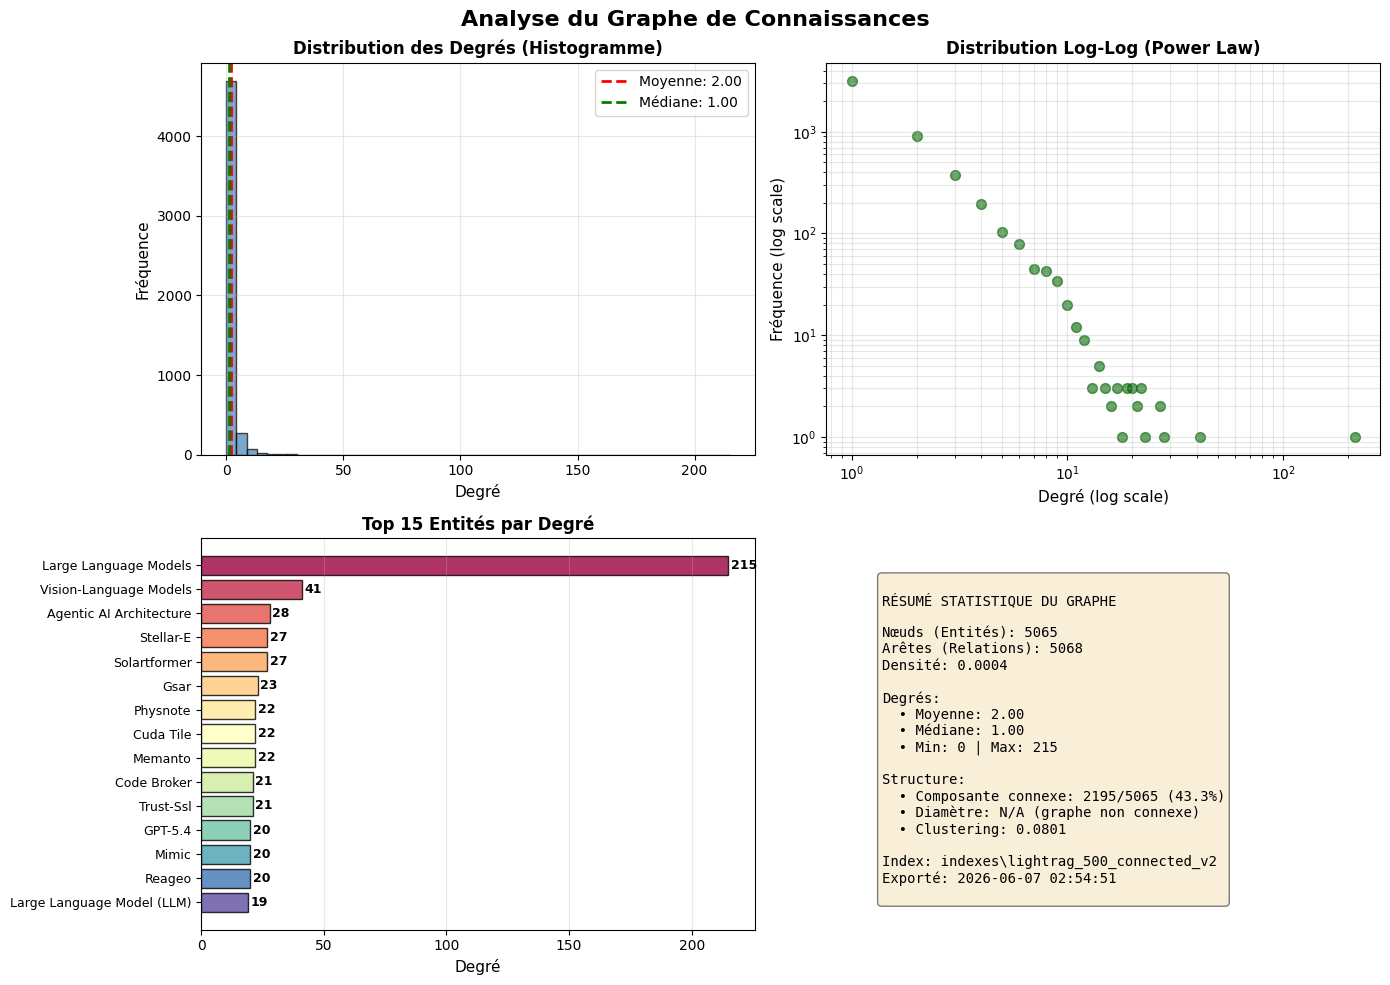

 Statistiques JSON sauvegardées: figures\graph_statistics_20260607_025453.json
ANALYSE COMPLÈTE


In [5]:
import matplotlib.pyplot as plt
import networkx as nx
from pathlib import Path
import numpy as np

# Créer répertoire figures s'il n'existe pas
FIGURES_DIR = BASE_DIR / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# ============================================================================
# CHARGER LE GRAPHE
# ============================================================================

GRAPHML_PATH = INDEX_DIR / 'graph_chunk_entity_relation.graphml'

if not GRAPHML_PATH.exists():
    raise FileNotFoundError(f"GraphML non trouvé: {GRAPHML_PATH}")

print(f" Chargement du graphe depuis: {GRAPHML_PATH}")
G = nx.read_graphml(str(GRAPHML_PATH))
print(f" Graphe chargé: {G.number_of_nodes()} nœuds, {G.number_of_edges()} arêtes")

# ============================================================================
# STATISTIQUES GLOBALES
# ============================================================================

n_nodes = G.number_of_nodes()
n_edges = G.number_of_edges()
density = nx.density(G)
avg_degree = sum(dict(G.degree()).values()) / n_nodes if n_nodes > 0 else 0

# Taille des plus grandes composantes connexes
if G.number_of_nodes() > 0:
    largest_cc = max(nx.connected_components(G.to_undirected()), key=len)
    largest_cc_size = len(largest_cc)
else:
    largest_cc_size = 0

# Diamètre (seulement si graphe connexe)
try:
    diameter = nx.diameter(G.to_undirected())
except:
    diameter = "N/A (graphe non connexe)"

# Distribution des degrés
degrees = [d for n, d in G.degree()]
avg_deg = np.mean(degrees) if degrees else 0
median_deg = np.median(degrees) if degrees else 0
max_deg = np.max(degrees) if degrees else 0
min_deg = np.min(degrees) if degrees else 0

print("\n" + "="*70)
print(" STATISTIQUES GLOBALES")
print("="*70)
print(f"Nœuds (entités): {n_nodes}")
print(f"Arêtes (relations): {n_edges}")
print(f"Densité: {density:.4f}")
print(f"Degré moyen: {avg_deg:.2f}")
print(f"Degré médian: {median_deg:.2f}")
print(f"Degré max: {max_deg}")
print(f"Degré min: {min_deg}")
print(f"Plus grande composante connexe: {largest_cc_size} nœuds ({100*largest_cc_size/n_nodes:.1f}%)")
print(f"Diamètre: {diameter}")

# Clusterisation
try:
    avg_clustering = nx.average_clustering(G.to_undirected())
    print(f"Coefficient de clusterisation moyen: {avg_clustering:.4f}")
except:
    avg_clustering = "N/A"
    print(f"Coefficient de clusterisation moyen: N/A")

# ============================================================================
# TOP ENTITÉS PAR DEGRÉ
# ============================================================================

print("\n" + "="*70)
print("TOP 15 ENTITÉS PAR DEGRÉ")
print("="*70)

degree_dict = dict(G.degree())
top_nodes = sorted(degree_dict.items(), key=lambda x: x[1], reverse=True)[:15]

top_nodes_table = []
for i, (node, deg) in enumerate(top_nodes, 1):
    node_name = G.nodes[node].get('name', node)[:50]  # Truncate pour lisibilité
    top_nodes_table.append((i, node_name, deg))
    print(f"{i:2d}. {node_name:50s} | degré={deg:3d}")

# ============================================================================
# VISUALISATIONS
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Analyse du Graphe de Connaissances', fontsize=16, fontweight='bold')

# 1. Histogramme des degrés
ax1 = axes[0, 0]
ax1.hist(degrees, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
ax1.axvline(avg_deg, color='red', linestyle='--', linewidth=2, label=f'Moyenne: {avg_deg:.2f}')
ax1.axvline(median_deg, color='green', linestyle='--', linewidth=2, label=f'Médiane: {median_deg:.2f}')
ax1.set_xlabel('Degré', fontsize=11)
ax1.set_ylabel('Fréquence', fontsize=11)
ax1.set_title('Distribution des Degrés (Histogramme)', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Graphique log-log (power law)
ax2 = axes[0, 1]
degree_counts = np.bincount(degrees)
degree_bins = np.where(degree_counts > 0)[0]
degree_freq = degree_counts[degree_bins]
ax2.scatter(degree_bins, degree_freq, alpha=0.6, s=50, color='darkgreen')
ax2.set_xlabel('Degré (log scale)', fontsize=11)
ax2.set_ylabel('Fréquence (log scale)', fontsize=11)
ax2.set_title('Distribution Log-Log (Power Law)', fontsize=12, fontweight='bold')
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.grid(True, alpha=0.3, which='both')

# 3. Top 15 entités par degré
ax3 = axes[1, 0]
top_names = [name[:30] for name, _ in top_nodes]  # Truncate pour le graphique
top_degs = [deg for _, deg in top_nodes]
colors = plt.cm.Spectral(np.linspace(0, 1, len(top_names)))
bars = ax3.barh(range(len(top_names)), top_degs, color=colors, edgecolor='black', alpha=0.8)
ax3.set_yticks(range(len(top_names)))
ax3.set_yticklabels(top_names, fontsize=9)
ax3.set_xlabel('Degré', fontsize=11)
ax3.set_title('Top 15 Entités par Degré', fontsize=12, fontweight='bold')
ax3.invert_yaxis()
ax3.grid(True, alpha=0.3, axis='x')

# Ajouter valeurs sur les barres
for i, (bar, deg) in enumerate(zip(bars, top_degs)):
    ax3.text(deg + 1, i, str(deg), va='center', fontsize=9, fontweight='bold')

# 4. Statistiques textuelles
ax4 = axes[1, 1]
ax4.axis('off')
stats_text = f"""
RÉSUMÉ STATISTIQUE DU GRAPHE

Nœuds (Entités): {n_nodes}
Arêtes (Relations): {n_edges}
Densité: {density:.4f}

Degrés:
  • Moyenne: {avg_deg:.2f}
  • Médiane: {median_deg:.2f}
  • Min: {min_deg} | Max: {max_deg}

Structure:
  • Composante connexe: {largest_cc_size}/{n_nodes} ({100*largest_cc_size/n_nodes:.1f}%)
  • Diamètre: {diameter}
  • Clustering: {avg_clustering if isinstance(avg_clustering, str) else f'{avg_clustering:.4f}'}

Index: {INDEX_DIR}
Exporté: {time.strftime('%Y-%m-%d %H:%M:%S')}
"""
ax4.text(0.1, 0.9, stats_text, fontsize=10, verticalalignment='top',
         fontfamily='monospace', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()

# Sauvegarder la figure
fig_path = FIGURES_DIR / f'graph_statistics_{time.strftime("%Y%m%d_%H%M%S")}.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
print(f"\n Figure sauvegardée: {fig_path}")
plt.show()

# ============================================================================
# SAUVEGARDER LES STATISTIQUES EN JSON
# ============================================================================

stats_json = {
    "timestamp": time.strftime("%Y-%m-%d %H:%M:%S"),
    "global": {
        "nodes": n_nodes,
        "edges": n_edges,
        "density": float(density),
        "avg_degree": float(avg_deg),
        "median_degree": float(median_deg),
        "min_degree": int(min_deg),
        "max_degree": int(max_deg),
        "largest_component_size": largest_cc_size,
        "largest_component_pct": float(100 * largest_cc_size / n_nodes) if n_nodes > 0 else 0,
    },
    "diameter": str(diameter),
    "clustering": float(avg_clustering) if isinstance(avg_clustering, float) else None,
    "top_nodes": [
        {"rank": i, "name": name, "degree": int(deg)}
        for i, (name, deg) in enumerate(top_nodes, 1)
    ],
    "degree_distribution": {
        "mean": float(avg_deg),
        "median": float(median_deg),
        "std": float(np.std(degrees)) if degrees else 0,
        "min": int(min_deg),
        "max": int(max_deg),
        "q25": float(np.percentile(degrees, 25)) if degrees else 0,
        "q75": float(np.percentile(degrees, 75)) if degrees else 0,
    }
}

stats_path = FIGURES_DIR / f'graph_statistics_{time.strftime("%Y%m%d_%H%M%S")}.json'
with open(stats_path, 'w', encoding='utf-8') as f:
    json.dump(stats_json, f, ensure_ascii=False, indent=2)
print(f" Statistiques JSON sauvegardées: {stats_path}")

print("ANALYSE COMPLÈTE")


## 5) Évaluation quantitative (latence + nodes traversed approx + RAGAS faithfulness)

### 5.1 — Évaluation quantitative du mode Hybrid (latence + nodes + RAGAS Faithfulness)

Benchmark complet du LightRAG en mode hybrid sur 3 questions de test. Mesures :
- **Latence** : temps de réponse par query
- **Nodes traversed** : nombre approximatif d'entités consultées
- **Contexts** : chunks récupérés
- **RAGAS Faithfulness** : pourcentage de la réponse fidèle aux contextes (via LLM Ollama)

Résultats sauvegardés en JSON pour analyse comparative.

In [12]:
import json
import time
import asyncio
from pathlib import Path

from datasets import Dataset
from lightrag import QueryParam
from ragas.run_config import RunConfig


# ============================================================
# CONFIG
# ============================================================

BENCHMARK_PATH = Path("data/processed/arxiv_multihop_v1.json")

# rag = ton objet LightRAG déjà chargé

# ============================================================
# CHARGER UNIQUEMENT LES VRAIS MULTI-HOP
# ============================================================

with open(BENCHMARK_PATH, encoding="utf-8") as f:
    benchmark_all = json.load(f)

benchmark = [
    q for q in benchmark_all
    if q["supporting_chunks"][0] != q["supporting_chunks"][1]
]

print(f"Questions benchmark total : {len(benchmark_all)}")
print(f"True multi-hop uniquement : {len(benchmark)}")

# ============================================================
# UTILS
# ============================================================

def count_traversed_nodes(result_obj):
    try:
        ro = getattr(result_obj, "retriever_output", None)

        if ro is None and isinstance(result_obj, dict):
            ro = result_obj.get("retriever_output")

        if not ro:
            return 0

        if isinstance(ro, dict):
            nodes = (
                ro.get("nodes")
                or ro.get("entity_nodes")
                or ro.get("entities")
            )

            if isinstance(nodes, list):
                return len({str(x) for x in nodes})

        return 0

    except Exception:
        return 0

# ============================================================
# BENCHMARK LIGHTRAG
# ============================================================

async def run_benchmark(rag, benchmark):

    rows = []

    for i, ex in enumerate(benchmark):

        question = ex["question"]

        t0 = time.time()

        answer = await rag.aquery(
            question,
            param=QueryParam(
                mode="hybrid",
                top_k=40,
                chunk_top_k=20,
                enable_rerank=False,
            ),
        )
        
        print(type(answer))
        print(answer)
        print("=" * 100)

        latency = round(time.time() - t0, 2)

        context = await rag.aquery(
            question,
            param=QueryParam(
                mode="hybrid",
                only_need_context=True,
                top_k=10,
                chunk_top_k=5,
                enable_rerank=False,
            ),
        )

        contexts = (
            context
            if isinstance(context, list)
            else [str(context)]
        )

        row = {
            "question": question,
            "ground_truth": ex["ground_truth"],
            "answer": str(answer),
            "reasoning": ex.get("reasoning", ""),
            "supporting_chunks": ex["supporting_chunks"],
            "hop1": ex["hop1"],
            "hop2": ex["hop2"],
            "latency_s": latency,
            "nodes_traversed_approx": count_traversed_nodes(answer),
            "contexts": contexts,
        }

        rows.append(row)

        print(
            f"[{i+1}/{len(benchmark)}] "
            f"latency={latency}s | "
            f"{question[:80]}"
        )

    output_file = (
        OUT_DIR /
        "resultat_evaluation_lightrag_true_multihop.json"
    )

    with open(output_file, "w", encoding="utf-8") as f:
        json.dump(
            rows,
            f,
            ensure_ascii=False,
            indent=2
        )

    print("\nSauvegardé :", output_file)

    return rows

# ============================================================
# EXECUTION
# ============================================================

bench_rows = asyncio.run(
    run_benchmark(rag, benchmark)
)

# ============================================================
# RAGAS
# ============================================================

try:

    from ragas import evaluate

    try:
        from ragas.metrics import faithfulness
        metrics = [faithfulness]

    except Exception:
        from ragas.metrics import Faithfulness
        metrics = [Faithfulness()]

    from langchain_community.llms.ollama import Ollama

    ragas_ds = Dataset.from_list(
        [
            {
                "question": r["question"],
                "answer": r["answer"],
                "contexts": r["contexts"],
                "ground_truth": r["ground_truth"],
            }
            for r in bench_rows
        ]
    )

    llm_eval = Ollama(
        model=MODEL_NAME,
        base_url=OLLAMA_URL,
    )

    scores = evaluate(
        ragas_ds,
        metrics=metrics,
        llm=llm_eval,
        run_config=RunConfig(timeout=900),
        batch_size=1,
        raise_exceptions=False,
    )

    print("\n=== RAGAS ===")
    print(scores)

    scores.to_pandas().to_json(
        OUT_DIR / "ragas_lightrag_true_multihop.json",
        orient="records",
        force_ascii=False,
        indent=2,
    )

except ModuleNotFoundError as e:

    print(
        "RAGAS non exécuté (dépendance manquante) :",
        e,
    )

except Exception as e:

    print(
        "Erreur pendant l'évaluation RAGAS :",
        e,
    )

c:\Users\ADMIN\Desktop\PFE_Agentic_Graphrag\GraphRag_PFE\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
INFO: LLM func: 1 new workers initialized (Timeouts: Func: 180s, Worker: 360s, Health Check: 375s)


Questions benchmark total : 250
True multi-hop uniquement : 10
######### LOCAL LLM CALLED #########

LOCAL_LLM_FUNC
EXTRACTION = False
NUM_PREDICT = 900
PROMPT LEN = 2935
SYSTEM PROMPT EXISTS = False
PROMPT START:
---Role---
You are an expert keyword extractor, specializing in analyzing user queries for a Retrieval-Augmented Generation (RAG) system. Your purpose is to identify both high-level and low-level keywords in the user's query that will be used for effective document retrieval.

---Goal---
Given a user query, your task is to extract two distinct types of keywords:
1. **high_level_keywords**: for overarching concepts or themes, capturing user's core intent, the subject area, or the type of question

NB MESSAGES = 1
PROMPT LEN = 2935

MESSAGE 0
ROLE : user
LEN  : 2935
---Role---
You are an expert keyword extractor, specializing in analyzing user queries for a Retrieval-Augmented Generation (RAG) system. Your purpose is to identify both high-level and low-level keywords in the use

INFO:  == LLM cache == saving: hybrid:keywords:2ee41c8cd183afecd89a8b8e5826a932
INFO: Embedding func: 8 new workers initialized (Timeouts: Func: 30s, Worker: 60s, Health Check: 75s)


OUTPUT LEN = 191
OUTPUT START = '{\n  "high_level_keywords": ["Time series data", "PyPOTS", "Fine-tuning", "One-shot learning"],\n  "low_level_keywords": ["Partially-observed data", "In-context learning", "Task criticality"]\n}'


INFO: Query nodes: Partially-observed data, In-context learning, Task criticality (top_k:40, cosine:0.2)
INFO: Local query: 40 entites, 91 relations
INFO: Query edges: Time series data, PyPOTS, Fine-tuning, One-shot learning (top_k:40, cosine:0.2)
INFO: Global query: 66 entites, 40 relations
INFO: Raw search results: 97 entities, 121 relations, 0 vector chunks
INFO: After truncation: 97 entities, 121 relations
INFO: Selecting 159 from 159 entity-related chunks by vector similarity
INFO: Find no additional relations-related chunks from 121 relations
INFO: Round-robin merged chunks: 159 -> 159 (deduplicated 0)
INFO: Final context: 97 entities, 121 relations, 20 chunks
INFO: Final chunks S+F/O: E1/1 E3/2 E10/3 E4/4 E1/5 E3/6 E1/7 E3/8 E3/9 E2/10 E2/11 E1/12 E1/13 E1/14 E1/15 E1/16 E1/17 E3/18 E2/19 E1/20


...

INFO:  == LLM cache == saving: hybrid:keywords:c940f6dad7a5d7791b982a9d4ea3ac89


OUTPUT LEN = 177
OUTPUT START = '{\n  "high_level_keywords": ["Chain-of-Thought method", "Multiple thinkers"],\n  "low_level_keywords": ["Artificial intelligence", "Machine learning", "Cognitive architectures"]\n}'


INFO: Query nodes: Artificial intelligence, Machine learning, Cognitive architectures (top_k:40, cosine:0.2)
INFO: Local query: 40 entites, 427 relations
INFO: Query edges: Chain-of-Thought method, Multiple thinkers (top_k:40, cosine:0.2)
INFO: Global query: 68 entites, 40 relations
INFO: Raw search results: 104 entities, 463 relations, 0 vector chunks
INFO: After truncation: 73 entities, 161 relations
INFO: Selecting 182 from 192 entity-related chunks by vector similarity
INFO: Find 12 additional chunks in 12 relations (deduplicated 100)
INFO: Selecting 12 from 12 relation-related chunks by vector similarity
INFO: Round-robin merged chunks: 194 -> 194 (deduplicated 0)
INFO: Final context: 73 entities, 161 relations, 20 chunks
INFO: Final chunks S+F/O: E6/1 R2/1 E2/2 R1/2 E3/3 R1/3 E1/4 R1/4 E1/5 R1/5 E2/6 R1/6 E3/7 R2/7 E2/8 R1/8 E1/9 R1/9 E3/10 R1/10


######### LOCAL LLM CALLED #########

LOCAL_LLM_FUNC
EXTRACTION = False
NUM_PREDICT = 900
PROMPT LEN = 76
SYSTEM PROMPT EXISTS = True
PROMPT START:
What can be solved using the Chain-of-Thought method from multiple thinkers?

NB MESSAGES = 2
PROMPT LEN = 76

MESSAGE 0
ROLE : system
LEN  : 101297
---Role---
You are a RAG assistant.

---Rules---
1. Use only provided context.
2. If answer is not in context, say so briefly.

---Context---

Knowledge Graph Data (Entity):

```json
{"entity": "Artificial Intelligence", "type": "concept", "description": "Artificial Intelligence refers to the applic

MESSAGE 1
ROLE : user
LEN  : 76
What can be solved using the Chain-of-Thought method from multiple thinkers?


KeyboardInterrupt: 

In [21]:
import asyncio
from lightrag import QueryParam

async def debug_first_question():

    q = benchmark[0]["question"]

    print("\nQUESTION:")
    print(q)

    # ===== DEBUG CACHE =====

    cache = rag.llm_response_cache._data

    found = False

    for k, v in cache.items():

        if (
            v.get("cache_type") == "query"
            and v.get("original_prompt") == q
        ):
            found = True

            print("\n" + "="*100)
            print("CACHE FOUND")
            print("="*100)

            print("KEY :", k)

            print("\nQUERYPARAM CACHE:")
            print(v.get("queryparam"))

            break

    if not found:
        print("\n" + "="*100)
        print("CACHE NOT FOUND")
        print("="*100)

    # ===== APPEL LIGHTRAG =====

    print("\n" + "="*100)
    print("REQUETE LIGHTRAG")
    print("="*100)

    res = await rag.aquery(
        q,
        param=QueryParam(
            mode="hybrid",
            top_k=5,
            chunk_top_k=5,
            enable_rerank=False,
        ),
    )

    print("\nRESULTAT:")
    print(res)

asyncio.run(debug_first_question())


QUESTION:
What task is critical to processing partially-observed time series data with PyPOTS and also evaluated through fine-tuning and one-shot in-context learning?

CACHE FOUND
KEY : hybrid:query:78a8b67a37ce7bc6b488773c5255f797

QUERYPARAM CACHE:
{'mode': 'hybrid', 'response_type': 'Multiple Paragraphs', 'top_k': 40, 'chunk_top_k': 20, 'max_entity_tokens': 6000, 'max_relation_tokens': 8000, 'max_total_tokens': 30000, 'hl_keywords': 'Time series data, PyPOTS, Fine-tuning, One-shot learning', 'll_keywords': 'Partially-observed data, In-context learning, Task criticality', 'user_prompt': '', 'enable_rerank': False}

REQUETE LIGHTRAG


INFO: Query nodes: Partially-observed data, In-context learning, Task criticality (top_k:5, cosine:0.2)
INFO: Local query: 5 entites, 7 relations
INFO: Query edges: Time series data, PyPOTS, Fine-tuning, One-shot learning (top_k:5, cosine:0.2)
INFO: Global query: 9 entites, 5 relations
INFO: Raw search results: 13 entities, 11 relations, 0 vector chunks
INFO: After truncation: 13 entities, 11 relations
INFO: Selecting 6 from 6 entity-related chunks by vector similarity
INFO: Find no additional relations-related chunks from 11 relations
INFO: Round-robin merged chunks: 6 -> 6 (deduplicated 0)
INFO: Final context: 13 entities, 11 relations, 5 chunks
INFO: Final chunks S+F/O: E3/1 E7/2 E1/3 E1/4 E1/5
INFO:  == LLM cache == Query cache hit, using cached response as query result



RESULTAT:
Model training is the process of developing and fine-tuning machine learning models on partially-observed time series data. It is a critical task in processing partially-observed time series data with PyPOTS, as mentioned in the relationship between "Evaluation" and "Model Training". 

In-context learning is also evaluated through fine-tuning and one-shot in-context learning. In-context learning is an advanced prompt engineering strategy used for analyzing scientific texts according to a given classification scheme.


In [24]:
print(local_llm_func)
print(id(local_llm_func))
print(id(rag.llm_model_func))
print(local_llm_func is rag.llm_model_func)
print(rag.llm_model_func)

<function local_llm_func at 0x0000020B9BDC59E0>
2248882805216
2250634989696
False
<function priority_limit_async_func_call.<locals>.final_decro.<locals>.wait_func at 0x0000020C044C9080>


In [20]:
import os
import glob

for f in glob.glob(str(INDEX_DIR / "kv_store_llm*")):
    os.remove(f)
    print("Supprimé :", f)

with open(INDEX_DIR / "kv_store_llm_response_cache.json", "w") as f:
    f.write("{}")

Supprimé : indexes\lightrag_500_connected_v2\kv_store_llm_response_cache.json


In [14]:
q = benchmark[0]["question"]

context = await rag.aquery(
    q,
    param=QueryParam(
        mode="hybrid",
        only_need_context=True,
        top_k=40,
        chunk_top_k=20,
    ),
)

prompt = f"""
Based on the following context, answer the question.

Context:
{context}

Question:
{q}

Answer:
"""

resp = await local_llm_func(prompt)

print(type(resp))
print(repr(resp))
print(len(resp))

INFO: Query nodes: Partially-observed data, In-context learning, Task criticality (top_k:40, cosine:0.2)
INFO: Local query: 40 entites, 91 relations
INFO: Query edges: Time series data, PyPOTS, Fine-tuning, One-shot learning (top_k:40, cosine:0.2)
INFO: Global query: 66 entites, 40 relations
INFO: Raw search results: 97 entities, 121 relations, 0 vector chunks
INFO: After truncation: 97 entities, 121 relations
INFO: Selecting 159 from 159 entity-related chunks by vector similarity
INFO: Find no additional relations-related chunks from 121 relations
INFO: Round-robin merged chunks: 159 -> 159 (deduplicated 0)
INFO: Final context: 97 entities, 121 relations, 20 chunks
INFO: Final chunks S+F/O: E1/1 E3/2 E10/3 E4/4 E1/5 E3/6 E1/7 E3/8 E3/9 E2/10 E2/11 E1/12 E1/13 E1/14 E1/15 E1/16 E1/17 E3/18 E2/19 E1/20


######### LOCAL LLM CALLED #########

LOCAL_LLM_FUNC
EXTRACTION = False
NUM_PREDICT = 900
PROMPT LEN = 86680
SYSTEM PROMPT EXISTS = False
PROMPT START:

Based on the following context, answer the question.

Context:

Knowledge Graph Data (Entity):

```json
{"entity": "Classification", "type": "task", "description": "Classification is a type of machine learning task that involves assigning labels to partially-observed time series data."}
{"entity": "Partially-Observed Time Series", "type": "concept", "description": "Partially-observed time series refers to data where some values are missing or unknown."}
{"entity": "In-Context Learning", "type":

NB MESSAGES = 1
PROMPT LEN = 86680

MESSAGE 0
ROLE : user
LEN  : 86680

Based on the following context, answer the question.

Context:

Knowledge Graph Data (Entity):

```json
{"entity": "Classification", "type": "task", "description": "Classification is a type of machine learning task that involves assigning labels to partially-observed time s

In [27]:
question = benchmark[0]["question"]

ctx = await rag.aquery(
    question,
    param=QueryParam(
        mode="hybrid",
        only_need_context=True,
        top_k=10,
        chunk_top_k=5,
    ),
)

print("="*100)
print(ctx)
print("="*100)

INFO: Query nodes: Partially-observed data, In-context learning, Task criticality (top_k:10, cosine:0.2)
INFO: Local query: 10 entites, 20 relations
INFO: Query edges: Time series data, PyPOTS, Fine-tuning, One-shot learning (top_k:10, cosine:0.2)
INFO: Global query: 18 entites, 10 relations
INFO: Raw search results: 26 entities, 28 relations, 0 vector chunks
INFO: After truncation: 26 entities, 28 relations
INFO: Selecting 24 from 24 entity-related chunks by vector similarity
INFO: Find no additional relations-related chunks from 28 relations
INFO: Round-robin merged chunks: 24 -> 24 (deduplicated 0)
INFO: Final context: 26 entities, 28 relations, 5 chunks
INFO: Final chunks S+F/O: E3/1 E9/2 E2/3 E3/4 E2/5



Knowledge Graph Data (Entity):

```json
{"entity": "Classification", "type": "task", "description": "Classification is a type of machine learning task that involves assigning labels to partially-observed time series data."}
{"entity": "Partially-Observed Time Series", "type": "concept", "description": "Partially-observed time series refers to data where some values are missing or unknown."}
{"entity": "In-Context Learning", "type": "variant", "description": "In-Context Learning is an advanced prompt engineering strategy used in this study for analyzing scientific texts according to a given classification scheme.<SEP>In-context learning is a variant used in the experimentation phase, where similarities between input data and in-context examples are measured."}
{"entity": "Pypots Tutorial", "type": "application", "description": "The PyPOTS tutorial is a comprehensive guide for practitioners and researchers working with partially-observed time series data."}
{"entity": "Model Training", 

## 6) Export Neo4j (GraphML → batch UNWIND)

### 6.1 — Export Neo4j (GraphML → Batch UNWIND)

Conversion du graphe LightRAG depuis le format GraphML vers Neo4j en utilisant les opérations batch avec UNWIND (performance optimale). Étapes :
1. Lecture du GraphML
2. Création des contraintes (Entity.id UNIQUE)
3. Nettoyage optionnel des entités anciennes
4. Insertion batch des nœuds (2000 par batch)
5. Insertion batch des relations RELATES_TO

Cette approche batch évite les timeout et les surcharges réseau.

In [18]:
import networkx as nx
from neo4j import GraphDatabase

GRAPHML_PATH = INDEX_DIR / 'graph_chunk_entity_relation.graphml'

def pick_relation_label(attrs: dict) -> str:
    keys = ['relationship_keywords','relation','predicate','type','label','keywords','relationship','edge_type']
    for k in keys:
        v = attrs.get(k)
        if v is not None and str(v).strip():
            return str(v).strip()
    return 'unknown'

def export_graphml_to_neo4j(graphml_path: Path, batch_size=2000, clear_only_entities=True):
    if not (NEO4J_URI and NEO4J_PASSWORD):
        raise ValueError('Set NEO4J_URI + NEO4J_PASSWORD dans .env')
    g = nx.read_graphml(str(graphml_path))

    def n_name(n):
        a = g.nodes[n]
        return a.get('name') or a.get('entity_name') or str(n)
    def n_type(n):
        a = g.nodes[n]
        return a.get('type') or a.get('entity_type') or ''
    def n_desc(n):
        a = g.nodes[n]
        return (a.get('description') or a.get('entity_description') or '')[:500]
    def e_desc(a):
        return (a.get('relationship_description') or a.get('description') or '')[:500]

    driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USER, NEO4J_PASSWORD))
    with driver.session() as session:
        session.run('CREATE CONSTRAINT IF NOT EXISTS FOR (e:Entity) REQUIRE e.id IS UNIQUE')
        if clear_only_entities:
            session.run('MATCH (n:Entity) DETACH DELETE n')

        nodes_rows = [{'id': str(n), 'name': n_name(n), 'type': n_type(n), 'description': n_desc(n)} for n in g.nodes()]
        cypher_nodes = """
        UNWIND $rows AS row
        MERGE (e:Entity {id: row.id})
        SET e.name = row.name,
            e.type = row.type,
            e.description = row.description
        """
        for i in tqdm(range(0, len(nodes_rows), batch_size), desc='Neo4j nodes'):
            session.run(cypher_nodes, rows=nodes_rows[i:i+batch_size])

        edges_rows = []
        for u, v, attrs in g.edges(data=True):
            edges_rows.append({'src': str(u), 'tgt': str(v), 'type': pick_relation_label(attrs), 'description': e_desc(attrs)})

        cypher_edges = """
        UNWIND $rows AS row
        MATCH (a:Entity {id: row.src})
        MATCH (b:Entity {id: row.tgt})
        MERGE (a)-[r:RELATES_TO {type: row.type}]->(b)
        SET r.description = row.description
        """
        for i in tqdm(range(0, len(edges_rows), batch_size), desc='Neo4j edges'):
            session.run(cypher_edges, rows=edges_rows[i:i+batch_size])

    driver.close()
    print('Neo4j import DONE:', g.number_of_nodes(), 'nodes |', g.number_of_edges(), 'edges')

export_graphml_to_neo4j(GRAPHML_PATH)


Neo4j edges: 100%|██████████| 3/3 [00:00<00:00,  3.68it/s]

Neo4j import DONE: 5065 nodes | 5068 edges


### 6.2 — Requêtes exploratives Neo4j (10 analyses du graphe)

Exécution de 10 requêtes Cypher pour caractériser le graphe de connaissances :
1. Top entités connectées (degré)
2. Types de relations fréquents
3. Entités isolées
4. Paires d'entités les plus reliées
5. Chemins court LLM <-> GNN
6. Sous-graphe thématique LLM
7. Sous-graphe thématique RAG
8. Sous-graphe thématique GNN
9. Statistiques de degré (moyen, max, min)
10. Détection de communautés avec Louvain 

Résultats exportés en JSON pour visualisation et analyse.

In [ ]:
from neo4j import GraphDatabase
import json

NEO4J_EXPLORATION_OUT = OUT_DIR / "neo4j_exploratory_queries_results.json"

cypher_queries = {
    "01_top_connected_entities": """
    MATCH (e:Entity)-[r]-()
    RETURN e.name AS entity, e.type AS type, count(r) AS degree
    ORDER BY degree DESC
    LIMIT 20
    """,

    "02_relation_type_counts": """
    MATCH ()-[r:RELATES_TO]->()
    RETURN r.type AS relation_type, count(*) AS count
    ORDER BY count DESC
    LIMIT 30
    """,

    "03_isolated_entities": """
    MATCH (e:Entity)
    WHERE NOT (e)--()
    RETURN e.name AS entity, e.type AS type
    LIMIT 50
    """,

    "04_top_entity_pairs": """
    MATCH (a:Entity)-[r:RELATES_TO]->(b:Entity)
    RETURN a.name AS source, b.name AS target, r.type AS relation, count(*) AS count
    ORDER BY count DESC
    LIMIT 30
    """,

    "05_shortest_path_llm_gnn": """
    MATCH (a:Entity), (b:Entity)
    WHERE toLower(a.name) CONTAINS 'language model'
      AND toLower(b.name) CONTAINS 'graph neural'
    MATCH p = shortestPath((a)-[:RELATES_TO*..5]-(b))
    RETURN [n IN nodes(p) | n.name] AS path, length(p) AS hops
    LIMIT 10
    """,

    "06_llm_thematic_subgraph": """
    MATCH (a:Entity)-[r:RELATES_TO]-(b:Entity)
    WHERE toLower(a.name) CONTAINS 'llm'
       OR toLower(a.name) CONTAINS 'language model'
       OR toLower(b.name) CONTAINS 'llm'
       OR toLower(b.name) CONTAINS 'language model'
    RETURN a.name AS source, r.type AS relation, b.name AS target
    LIMIT 80
    """,

    "07_rag_thematic_subgraph": """
    MATCH (a:Entity)-[r:RELATES_TO]-(b:Entity)
    WHERE toLower(a.name) CONTAINS 'retrieval'
       OR toLower(a.name) CONTAINS 'rag'
       OR toLower(b.name) CONTAINS 'retrieval'
       OR toLower(b.name) CONTAINS 'rag'
    RETURN a.name AS source, r.type AS relation, b.name AS target
    LIMIT 80
    """,

    "08_gnn_thematic_subgraph": """
    MATCH (a:Entity)-[r:RELATES_TO]-(b:Entity)
    WHERE toLower(a.name) CONTAINS 'graph neural'
       OR toLower(b.name) CONTAINS 'graph neural'
    RETURN a.name AS source, r.type AS relation, b.name AS target
    LIMIT 80
    """,

    "09_graph_degree_summary": """
    MATCH (e:Entity)
    OPTIONAL MATCH (e)-[r]-()
    WITH e, count(r) AS degree
    RETURN count(e) AS nodes,
           avg(degree) AS avg_degree,
           max(degree) AS max_degree,
           min(degree) AS min_degree
    """,

    "10_community_detection_gds": """
    CALL gds.graph.project(
      'entityGraph',
      'Entity',
      {RELATES_TO: {orientation: 'UNDIRECTED'}
    )
    YIELD graphName, nodeCount, relationshipCount
    RETURN graphName, nodeCount, relationshipCount
    """
}

def run_neo4j_exploration():
    driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USER, NEO4J_PASSWORD))
    results = {}

    with driver.session() as session:
        for name, query in cypher_queries.items():
            try:
                rows = [dict(r) for r in session.run(query)]
                results[name] = rows
                print(name, "OK", len(rows), "rows")
            except Exception as e:
                results[name] = {"error": str(e)}
                print(name, "ERROR:", str(e)[:200])

        try:
            community_query = """
            CALL gds.louvain.stream('entityGraph')
            YIELD nodeId, communityId
            WITH communityId, collect(gds.util.asNode(nodeId).name)[0..15] AS sample_entities, count(*) AS size
            RETURN communityId, size, sample_entities
            ORDER BY size DESC
            LIMIT 10
            """
            results["10b_louvain_communities"] = [dict(r) for r in session.run(community_query)]
            print("10b_louvain_communities OK")
        except Exception as e:
            results["10b_louvain_communities"] = {"error": str(e)}
            print("GDS Louvain ERROR:", str(e)[:200])

    driver.close()

    with open(NEO4J_EXPLORATION_OUT, "w", encoding="utf-8") as f:
        json.dump(results, f, ensure_ascii=False, indent=2)

    print("Saved:", NEO4J_EXPLORATION_OUT)
    return results

neo4j_results = run_neo4j_exploration()

01_top_connected_entities OK 20 rows
02_relation_type_counts OK 30 rows
03_isolated_entities OK 28 rows
04_top_entity_pairs OK 30 rows


INFO:neo4j.notifications:Received notification from DBMS server: <GqlStatusObject gql_status='03N90', status_description="info: cartesian product. The disconnected pattern '(a:Entity), (b:Entity)' builds a cartesian product. A cartesian product may produce a large amount of data and slow down query processing.", position=<SummaryInputPosition line=2, column=5, offset=5>, raw_classification='PERFORMANCE', classification=<NotificationClassification.PERFORMANCE: 'PERFORMANCE'>, raw_severity='INFORMATION', severity=<NotificationSeverity.INFORMATION: 'INFORMATION'>, diagnostic_record={'_classification': 'PERFORMANCE', '_severity': 'INFORMATION', '_position': {'offset': 5, 'line': 2, 'column': 5}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: "\n    MATCH (a:Entity), (b:Entity)\n    WHERE toLower(a.name) CONTAINS 'language model'\n      AND toLower(b.name) CONTAINS 'graph neural'\n    MATCH p = shortestPath((a)-[:RELATES_TO*..5]-(b))\n    RETURN [n IN nodes(p) | 

05_shortest_path_llm_gnn OK 3 rows
06_llm_thematic_subgraph OK 80 rows
07_rag_thematic_subgraph OK 80 rows
08_gnn_thematic_subgraph OK 28 rows
09_graph_degree_summary OK 1 rows
10_community_detection_gds ERROR: {neo4j_code: Neo.ClientError.Procedure.ProcedureNotFound} {message: There is no procedure with the name `gds.graph.project` registered for this database instance. Please ensure you've spelled the proc
GDS Louvain ERROR: {neo4j_code: Neo.ClientError.Procedure.ProcedureNotFound} {message: There is no procedure with the name `gds.louvain.stream` registered for this database instance. Please ensure you've spelled the pro
Saved: data\processed\triplets\neo4j_exploratory_queries_results.json


## 7) Comparaison entre triplets

### 7.1 — Extraction NER + RE avec spaCy et REBEL (rappel++)

Pipeline complet d'extraction alternatif basé sur modèles entraînés (pas LLM) :
- **spaCy** : segmentation offline des phrases (sentencizer)
- **REBEL** : extraction des triplets (head, relation, tail) en seq2seq
- **Fenêtres de phrases** : technique de rappel++ pour couvrir plus de contexte (window=3 phrases, step=2)
- **Parsing strict** : normalisation, dédup locale, filtrage entités trop courtes
- **Checkpoint** : sauvegarde tous les 25 documents

Avantages vs LightRAG : pas de dépendance au LLM, extraction plus stable, relations propres (instance_of, subclass_of, use, etc.)
Durée : ~1.1 heure pour 500 documents.

In [ ]:
import os
import re
import json
import time
import warnings
from pathlib import Path
from collections import Counter

import torch
from tqdm import tqdm
import spacy
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM


# ──────────────────────────────────────────────────────────────
# CONFIG
# ──────────────────────────────────────────────────────────────
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

INPUT_FILE = Path("data/processed/arxiv_cleaned.json")
OUTPUT_DIR = Path("data/processed/triplets")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_FILE = OUTPUT_DIR / "rebel_triplets_entities_recallpp.json"
CHECKPOINT_FILE = OUTPUT_DIR / "checkpoint_rebel_recallpp.json"
SAVE_EVERY = 25
MAX_DOCS = None  # None = tout le corpus

REBEL_MODEL_NAME = "Babelscape/rebel-large"

# REBEL (plus riche)
MAX_INPUT_TOKENS = 512
MAX_NEW_TOKENS = 512
NUM_BEAMS = 5  # un peu plus que 4 => parfois + de triplets (mais plus lent)

# Fenêtres de phrases (rappel++)
WINDOW_SENTENCES = 3      # fenêtre de 3 phrases (bon compromis contexte/rappel)
STEP_SENTENCES = 2        # avance de 2 => overlap 1 phrase
MIN_SENT_CHARS = 15       # phrases plus courtes acceptées

# Normalisation
LOWER_RELATION = True
MIN_ENTITY_LEN = 3

# réduire warnings
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")
warnings.filterwarnings("ignore", category=FutureWarning)

_ws = re.compile(r"\s+")


def clean_text(s: str) -> str:
    s = (s or "").replace("\n", " ").strip()
    return _ws.sub(" ", s)


def norm_ent(e: str) -> str:
    e = clean_text(e)
    return e.strip(" ,.;:()[]{}\"'")


def norm_rel(r: str) -> str:
    r = clean_text(r)
    return r.lower() if LOWER_RELATION else r


def parse_rebel(decoded_text: str):
    """
    Parser REBEL (conforme README Babelscape) :
      <triplet> SUBJECT <subj> OBJECT <obj> RELATION ...
    """
    triplets = []
    subject, relation, object_ = "", "", ""
    current = "x"

    tokens = (
        decoded_text.replace("<s>", "")
        .replace("<pad>", "")
        .replace("</s>", "")
        .split()
    )

    for tok in tokens:
        if tok == "<triplet>":
            current = "t"
            if relation.strip():
                triplets.append({"head": subject.strip(), "type": relation.strip(), "tail": object_.strip()})
            relation, subject = "", ""

        elif tok == "<subj>":
            current = "s"
            if relation.strip():
                triplets.append({"head": subject.strip(), "type": relation.strip(), "tail": object_.strip()})
            object_ = ""

        elif tok == "<obj>":
            current = "o"
            relation = ""

        else:
            if current == "t":
                subject += " " + tok
            elif current == "s":
                object_ += " " + tok
            elif current == "o":
                relation += " " + tok

    if subject.strip() and relation.strip() and object_.strip():
        triplets.append({"head": subject.strip(), "type": relation.strip(), "tail": object_.strip()})

    # normalisation + dédup locale
    seen = set()
    uniq = []
    for t in triplets:
        h = norm_ent(t["head"])
        r = norm_rel(t["type"])
        ta = norm_ent(t["tail"])

        if len(h) < MIN_ENTITY_LEN or len(ta) < MIN_ENTITY_LEN or len(r) < 2:
            continue
        if h.lower() == ta.lower():
            continue

        key = (h, r, ta)
        if key not in seen:
            seen.add(key)
            uniq.append({"head": h, "type": r, "tail": ta})
    return uniq


def rebel_extract_triplets(text_segment: str, tokenizer, model):
    enc = tokenizer(
        text_segment,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_INPUT_TOKENS
    )
    enc = {k: v.to(DEVICE) for k, v in enc.items()}

    with torch.inference_mode():
        gen_ids = model.generate(
            **enc,
            max_new_tokens=MAX_NEW_TOKENS,
            num_beams=NUM_BEAMS
        )

    decoded = tokenizer.decode(gen_ids[0], skip_special_tokens=False)
    return parse_rebel(decoded)


def dedup_triplets(triplets):
    seen = set()
    out = []
    for t in triplets:
        key = (t["head"], t["type"], t["tail"])
        if key not in seen:
            seen.add(key)
            out.append(t)
    return out


def derive_entities_from_triplets(triplets):
    """
    Entités = union(head, tail), dédupliqué.
    """
    ents = []
    seen = set()
    for t in triplets:
        for k in ("head", "tail"):
            e = norm_ent(t[k])
            if len(e) < MIN_ENTITY_LEN:
                continue
            key = e.lower()
            if key not in seen:
                seen.add(key)
                ents.append({"text": e})
    return ents


def build_sentence_windows(sentences, tokenizer):
    """
    Fenêtres de phrases avec overlap:
    - window = WINDOW_SENTENCES
    - step   = STEP_SENTENCES
    Chaque fenêtre doit respecter MAX_INPUT_TOKENS (sinon on réduit la fenêtre).
    """
    sents = [clean_text(s) for s in sentences if len(clean_text(s)) >= MIN_SENT_CHARS]
    windows = []
    n = len(sents)
    i = 0

    while i < n:
        # tentative fenêtre de WINDOW_SENTENCES
        j = min(i + WINDOW_SENTENCES, n)
        chunk = " ".join(sents[i:j]).strip()

        # si trop long, réduire jusqu'à rentrer dans MAX_INPUT_TOKENS
        while chunk:
            n_tokens = len(tokenizer(chunk, add_special_tokens=False)["input_ids"])
            if n_tokens <= MAX_INPUT_TOKENS:
                break
            # retirer la dernière phrase
            j -= 1
            if j <= i:
                # si même une phrase est trop longue, on tronque via tokenizer 
                chunk = sents[i]
                break
            chunk = " ".join(sents[i:j]).strip()

        if chunk:
            windows.append(chunk)

        if i + STEP_SENTENCES <= i:
            i += 1
        else:
            i += STEP_SENTENCES

    return windows


def main():
    print(f"Device : {DEVICE}")

    # spaCy offline segmentation
    print("Chargement spaCy (offline sentencizer)...")
    nlp = spacy.blank("en")
    nlp.add_pipe("sentencizer")

    # REBEL
    print("Chargement REBEL...")
    rebel_tokenizer = AutoTokenizer.from_pretrained(REBEL_MODEL_NAME)
    rebel_model = AutoModelForSeq2SeqLM.from_pretrained(REBEL_MODEL_NAME).to(DEVICE)
    if DEVICE == "cuda":
        rebel_model = rebel_model.half()
    rebel_model.eval()

    # Dataset
    print("\nChargement dataset...")
    papers = json.loads(INPUT_FILE.read_text(encoding="utf-8"))
    print(f"{len(papers)} documents chargés\n")
    if MAX_DOCS is not None:
        papers = papers[:MAX_DOCS]

    # Checkpoint
    start_idx = 0
    results = []
    global_rel_counter = Counter()
    parsing_success = 0
    total_triplets = 0
    total_entities = 0

    if CHECKPOINT_FILE.exists():
        ck = json.loads(CHECKPOINT_FILE.read_text(encoding="utf-8"))
        start_idx = ck.get("next_index", 0)
        results = ck.get("results", [])
        meta = ck.get("metadata_partial", {})
        parsing_success = meta.get("parsing_success", 0)
        total_triplets = meta.get("total_triplets", 0)
        total_entities = meta.get("total_entities", 0)
        global_rel_counter = Counter(ck.get("global_rel_counter", {}))
        print(f"[Checkpoint] Reprise à l’index {start_idx} (déjà {len(results)} docs).")

    t0 = time.time()

    for idx in tqdm(range(start_idx, len(papers)), desc="spaCy + REBEL (rappel++)"):
        p = papers[idx]
        title = clean_text(p.get("title", ""))
        abstract = clean_text(p.get("abstract", ""))
        full_text = clean_text(f"{title}. {abstract}")

        # segmentation -> fenêtres
        doc = nlp(full_text)
        sentences = [s.text for s in doc.sents]
        windows = build_sentence_windows(sentences, rebel_tokenizer)

        # REBEL sur chaque fenêtre
        doc_triplets = []
        for w in windows:
            doc_triplets.extend(rebel_extract_triplets(w, rebel_tokenizer, rebel_model))

        doc_triplets = dedup_triplets(doc_triplets)
        doc_entities = derive_entities_from_triplets(doc_triplets)

        if doc_triplets:
            parsing_success += 1

        total_triplets += len(doc_triplets)
        total_entities += len(doc_entities)
        for t in doc_triplets:
            global_rel_counter[t["type"]] += 1

        results.append({
            "id": p.get("id", ""),
            "title": title,
            "entities": doc_entities,
            "triplets": doc_triplets
        })

        if (idx + 1) % SAVE_EVERY == 0:
            ck = {
                "next_index": idx + 1,
                "results": results,
                "global_rel_counter": dict(global_rel_counter),
                "metadata_partial": {
                    "parsing_success": parsing_success,
                    "total_triplets": total_triplets,
                    "total_entities": total_entities
                }
            }
            CHECKPOINT_FILE.write_text(json.dumps(ck, ensure_ascii=False, indent=2), encoding="utf-8")

    nb_docs = len(results)
    taux = (parsing_success / max(nb_docs, 1)) * 100
    runtime = time.time() - t0

    out = {
        "metadata": {
            "nb_documents": nb_docs,
            "parsing_success": parsing_success,
            "taux_parsing_pct": round(taux, 2),
            "total_entities": total_entities,
            "total_triplets": total_triplets,
            "moy_triplets_par_doc": round(total_triplets / max(nb_docs, 1), 3),
            "runtime_sec": round(runtime, 2),
            "top_relations_20": global_rel_counter.most_common(20),
            "params": {
                "MAX_INPUT_TOKENS": MAX_INPUT_TOKENS,
                "MAX_NEW_TOKENS": MAX_NEW_TOKENS,
                "NUM_BEAMS": NUM_BEAMS,
                "WINDOW_SENTENCES": WINDOW_SENTENCES,
                "STEP_SENTENCES": STEP_SENTENCES,
                "MIN_SENT_CHARS": MIN_SENT_CHARS,
                "SPACY_MODE": "blank('en') + sentencizer (offline)"
            }
        },
        "results": results
    }

    OUTPUT_FILE.write_text(json.dumps(out, ensure_ascii=False, indent=2), encoding="utf-8")

    # Exemples réels
    print("\nExemples (docs les plus riches) :")
    top_docs = sorted(results, key=lambda r: len(r.get("triplets", [])), reverse=True)[:2]
    for d in top_docs:
        print(f"\n- {d['id']} | triplets={len(d['triplets'])} | entities={len(d['entities'])} | {d['title'][:90]}...")
        for t in d["triplets"][:10]:
            print(f"  → [{t['head']}] --{t['type']}--> [{t['tail']}]")

    print(f"\nSauvegardé dans {OUTPUT_FILE}")


if __name__ == "__main__":
    main()

c:\Users\ADMIN\Desktop\PFE_Agentic_Graphrag\GraphRag_PFE\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device : cpu
Chargement spaCy (offline sentencizer)...
Chargement REBEL...


Loading weights: 100%|██████████| 512/512 [00:00<00:00, 3401.61it/s]



Chargement dataset...
500 documents chargés



spaCy + REBEL (rappel++):   0%|          | 0/500 [00:00<?, ?it/s][transformers] Both `max_new_tokens` (=512) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=512) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=512) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=512) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refe


Exemples (docs les plus riches) :

- 2604.23747v1 | triplets=14 | entities=8 | SFT-then-RL Outperforms Mixed-Policy Methods for LLM Reasoning...
  → [SFT-then-RL] --part of--> [LLM]
  → [LLM] --has part--> [SFT-then-RL]
  → [LLM] --has part--> [TRL]
  → [LLM] --has part--> [OpenRLHF]
  → [LLM] --has part--> [Llama-Factory]
  → [TRL] --part of--> [LLM]
  → [OpenRLHF] --part of--> [LLM]
  → [Llama-Factory] --part of--> [LLM]
  → [TRL] --has part--> [LLama-Factory]
  → [Llama-Factory] --part of--> [TRL]

- 2604.22748v1 | triplets=13 | entities=12 | Agentic World Modeling: Foundations, Capabilities, Laws, and Beyond...
  → [AI systems] --has part--> [Agents]
  → [Agents] --part of--> [AI systems]
  → [L1 Predictor] --part of--> [L2 Simulator]
  → [L1 Predictor] --part of--> [L3 Evolver]
  → [L2 Simulator] --has part--> [L1 Predictor]
  → [L2 Simulator] --has part--> [L3 Evolver]
  → [L3 Evolver] --has part--> [L1 Predictor]
  → [L3 Evolver] --part of--> [L2 Simulator]
  → [physical] --ins

### 7.2 — Comparaison qualitative LightRAG vs REBEL

Analyse comparative détaillée des deux méthodes d'extraction :
- **Overlap exact** : triplets identiques
- **Overlap loose** : même paire d'entités (prédicat différent)
- **Top relations** : prédicats les plus fréquents par système
- **Exemples** : triplets exclusifs à chaque système

Génère :
- JSON `comparison_lightrag_vs_rebel_qualitative.json` : résumé stats + exemples
- CSV `manual_validation_50_triplets.csv` : 50 triplets aléatoires (25 LightRAG + 25 REBEL) pour validation manuelle

In [7]:
import json, re, random
import pandas as pd
from collections import Counter

LIGHTRAG_NV_PATH = OUT_DIR / "triplets_extraction_llm_500_NV_recovered.json"
LIGHTRAG_FALLBACK_PATH = OUT_DIR / "triplets_extraction_llm_500.json"
REBEL_PATH = OUT_DIR / "rebel_triplets_entities_recallpp.json"

COMPARISON_OUT = OUT_DIR / "comparison_lightrag_vs_rebel_qualitative.json"
MANUAL_CSV = OUT_DIR / "manual_validation_50_triplets.csv"

random.seed(42)

def norm(x):
    x = str(x or "").lower().strip()
    x = re.sub(r"[^a-z0-9]+", " ", x)
    return re.sub(r"\s+", " ", x).strip()

def key(t, loose=False):
    h = norm(t["head"])
    r = norm(t["relation"])
    ta = norm(t["tail"])
    return (h, ta) if loose else (h, r, ta)

def load_lightrag(path):
    data = json.loads(path.read_text(encoding="utf-8"))
    rows = []
    for doc in data.get("triplets", []):
        for r in doc.get("relations", []):
            rows.append({
                "source_system": "LightRAG",
                "doc_id": doc.get("doc_id", ""),
                "head": r.get("source", ""),
                "relation": r.get("relation_keywords", ""),
                "tail": r.get("target", "")
            })
    return rows, data.get("metadata", {})

def load_rebel(path):
    data = json.loads(path.read_text(encoding="utf-8"))
    rows = []
    for doc in data.get("results", []):
        for t in doc.get("triplets", []):
            rows.append({
                "source_system": "spaCy_REBEL",
                "doc_id": doc.get("id", ""),
                "head": t.get("head", ""),
                "relation": t.get("type", ""),
                "tail": t.get("tail", "")
            })
    return rows, data.get("metadata", {})

def dedup(rows):
    seen, out = set(), []
    for r in rows:
        k = key(r)
        if not all(k):
            continue
        if k not in seen:
            seen.add(k)
            out.append(r)
    return out

# LightRAG: utiliser NV si rempli, sinon fallback
light_rows, light_meta = load_lightrag(LIGHTRAG_NV_PATH)

if len(light_rows) == 0:
    print("WARNING: triplets_extraction_llm_500_NV.json est vide.")
    print("Utilisation du fichier fallback:", LIGHTRAG_FALLBACK_PATH)
    light_rows, light_meta = load_lightrag(LIGHTRAG_FALLBACK_PATH)

rebel_rows, rebel_meta = load_rebel(REBEL_PATH)

light_rows = dedup(light_rows)
rebel_rows = dedup(rebel_rows)

light_exact = {key(t) for t in light_rows}
rebel_exact = {key(t) for t in rebel_rows}

light_loose = {key(t, loose=True) for t in light_rows}
rebel_loose = {key(t, loose=True) for t in rebel_rows}

summary = {
    "lightrag_unique_triplets": len(light_rows),
    "rebel_unique_triplets": len(rebel_rows),
    "exact_overlap": len(light_exact & rebel_exact),
    "entity_pair_overlap": len(light_loose & rebel_loose),
    "lightrag_only": len(light_exact - rebel_exact),
    "rebel_only": len(rebel_exact - light_exact),
    "lightrag_top_relations": Counter([norm(t["relation"]) for t in light_rows]).most_common(20),
    "rebel_top_relations": Counter([norm(t["relation"]) for t in rebel_rows]).most_common(20),
}

comparison = {
    "summary": summary,
    "examples_lightrag_only": [t for t in light_rows if key(t) not in rebel_exact][:30],
    "examples_rebel_only": [t for t in rebel_rows if key(t) not in light_exact][:30],
    "examples_common": [t for t in light_rows if key(t) in rebel_exact][:30],
}

COMPARISON_OUT.write_text(
    json.dumps(comparison, ensure_ascii=False, indent=2),
    encoding="utf-8"
)

# 50 triplets à valider manuellement: 25 LightRAG + 25 spaCy_REBEL
sample_light = random.sample(light_rows, min(25, len(light_rows)))
sample_rebel = random.sample(rebel_rows, min(25, len(rebel_rows)))
manual_sample = sample_light + sample_rebel
random.shuffle(manual_sample)

manual_rows = []
for i, t in enumerate(manual_sample, start=1):
    other_exact = key(t) in (rebel_exact if t["source_system"] == "LightRAG" else light_exact)
    other_pair = key(t, loose=True) in (rebel_loose if t["source_system"] == "LightRAG" else light_loose)

    manual_rows.append({
        "validation_id": i,
        "source_system": t["source_system"],
        "doc_id": t["doc_id"],
        "head": t["head"],
        "relation": t["relation"],
        "tail": t["tail"],
        "exists_exactly_in_other_system": other_exact,
        "same_entity_pair_in_other_system": other_pair,
        "manual_is_correct": "",  # remplir: 1 correct, 0 incorrect
        "manual_error_type": "",  # entity_error, relation_error, hallucination, too_vague
        "manual_notes": ""
    })

manual_df = pd.DataFrame(manual_rows)
manual_df.to_csv(MANUAL_CSV, index=False, encoding="utf-8-sig")

print("=== Comparaison qualitative ===")
print(json.dumps(summary, ensure_ascii=False, indent=2))
print("Comparaison sauvegardée:", COMPARISON_OUT)
print("CSV validation manuelle sauvegardé:", MANUAL_CSV)
print("Remplis manual_is_correct avec 1 ou 0, puis lance la cellule suivante.")
manual_df.head()

=== Comparaison qualitative ===
{
  "lightrag_unique_triplets": 5066,
  "rebel_unique_triplets": 2788,
  "exact_overlap": 0,
  "entity_pair_overlap": 31,
  "lightrag_only": 5066,
  "rebel_only": 2788,
  "lightrag_top_relations": [
    [
      "model application task",
      25
    ],
    [
      "dataset evaluation model performance",
      23
    ],
    [
      "application method",
      22
    ],
    [
      "dataset usage method application",
      19
    ],
    [
      "evaluation performance",
      19
    ],
    [
      "comparison evaluation",
      19
    ],
    [
      "dataset model evaluation",
      18
    ],
    [
      "method application model usage",
      17
    ],
    [
      "framework component knowledge repository",
      17
    ],
    [
      "method application task relevance",
      17
    ],
    [
      "model comparison performance improvement",
      16
    ],
    [
      "dataset usage model application",
      16
    ],
    [
      "benchmarking evaluation

,validation_id,source_system,doc_id,head,relation,tail,exists_exactly_in_other_system,same_entity_pair_in_other_system,manual_is_correct,manual_error_type,manual_notes
0,1,LightRAG,2604.21999v2,Adaptive Computation Time (Act),"accuracy boost,performance comparison",Fixed-Depth Processing,False,False,,,
1,2,LightRAG,2604.21430v1,Cohen'S D,"effect size,metric",Moral Judgements,False,False,,,
2,3,LightRAG,2604.24618v1,Evaluating whether AI models would sabotage AI...,"model behavior,prefill awareness",Opus 4.7 Preview,False,False,,,
3,4,spaCy_REBEL,2604.24351v1,Diffusion Templates,use,Controllable diffusion,False,False,,,
4,5,spaCy_REBEL,2604.23530v1,MTRouter,instance of,LLM,False,False,,,


### Calcule de précision manuellement 

### 7.3 — Calcul de précision manuelle

Lecture du CSV `manual_validation_50_triplets.csv` (où l'utilisateur a rempli `manual_is_correct` avec 1 ou 0), puis calcul :
- **Précision globale** : % de triplets marqués corrects
- **Précision par système** : LightRAG vs REBEL séparément

Résultats sauvegardés en JSON `manual_validation_50_precision_report.json` pour documentation du rapport.

In [8]:
import json
import pandas as pd

MANUAL_CSV = OUT_DIR / "manual_validation_50_triplets.csv"
PRECISION_OUT = OUT_DIR / "manual_validation_50_precision_report.json"

df = pd.read_csv(MANUAL_CSV)

def parse_label(x):
    if pd.isna(x):
        return None
    s = str(x).strip().lower()
    if s in {"1", "yes", "y", "oui", "o", "true", "correct"}:
        return 1
    if s in {"0", "no", "n", "non", "false", "incorrect"}:
        return 0
    return None

df["_label"] = df["manual_is_correct"].apply(parse_label)
validated = df[df["_label"].notna()].copy()

if len(validated) == 0:
    print("Aucun triplet validé. Remplis manual_is_correct dans:", MANUAL_CSV)
else:
    overall_precision = validated["_label"].mean()

    by_system = (
        validated
        .groupby("source_system")["_label"]
        .agg(["count", "sum", "mean"])
        .reset_index()
        .rename(columns={
            "count": "validated_triplets",
            "sum": "correct_triplets",
            "mean": "precision"
        })
    )

    report = {
        "validated_triplets": int(len(validated)),
        "correct_triplets": int(validated["_label"].sum()),
        "overall_precision": round(float(overall_precision), 4),
        "overall_precision_pct": round(float(overall_precision) * 100, 2),
        "precision_by_system": by_system.to_dict(orient="records")
    }

    PRECISION_OUT.write_text(
        json.dumps(report, ensure_ascii=False, indent=2),
        encoding="utf-8"
    )

    print("=== Precision manuelle ===")
    print(json.dumps(report, ensure_ascii=False, indent=2))
    print("Rapport sauvegardé:", PRECISION_OUT)

Aucun triplet validé. Remplis manual_is_correct dans: data\processed\triplets\manual_validation_50_triplets.csv


### 8.1 — Benchmark RAG avec HotpotQA et ChromaDB (Chroma Vector Store) khso yt9ad !!!!

Évaluation complète d'un pipeline RAG naïf utilisant ChromaDB comme base vectorielle (alternative simple à LightRAG) :
1. **Load index** : Chroma stocké dans `indexes/chroma_pfe500_baseline/`
2. **Retrieve** : pour chaque question, récupérer top-5 chunks pertinents
3. **Generate** : appel Ollama pour générer réponse
4. **Evaluate** : exactitude (EM), recall support documents, RAGAS metrics (faithfulness, answer_relevancy, context_precision, context_recall)

Résultats exportés pour comparaison avec les autres méthodes.

In [27]:
import json, string, random
from pathlib import Path
from datasets import Dataset
from langchain_chroma import Chroma
from langchain_ollama import ChatOllama, OllamaEmbeddings
from ragas import evaluate
from ragas.metrics import (
    Faithfulness,
    AnswerRelevancy,
    ContextPrecision,
    ContextRecall,
)
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper
from ragas.run_config import RunConfig

# ── Config ────────────────────────────────────────────────────
CHROMA_DIR      = r"indexes\chroma_pfe500_baseline"
COLLECTION_NAME = "pfe_500_baseline"
BENCHMARK_PATH  = Path("data/processed/arxiv_multihop_v1_filtered.json")
INDEX_DIR       = Path("indexes/lightrag_500_connected_v2")

OLLAMA_URL     = "http://localhost:11434"
MODEL_NAME     = "llama3.1:8b"
EMBED_MODEL    = "nomic-embed-text"
OLLAMA_NUM_CTX = 8192
TOP_K          = 5

# ── Charger mapping chunk_id → doc_id arxiv ──────────────────
with open(INDEX_DIR / "kv_store_text_chunks.json", encoding="utf-8") as f:
    lightrag_chunks = json.load(f)

def chunk_to_docid(chunk_id: str) -> str:
    return lightrag_chunks.get(chunk_id, {}).get("file_path", "")

# ── Charger benchmark ─────────────────────────────────────────
with open(BENCHMARK_PATH, encoding="utf-8") as f:
    all_questions = json.load(f)

true_multihop   = [q for q in all_questions
                   if q["supporting_chunks"][0] != q["supporting_chunks"][1]]
pseudo_multihop = [q for q in all_questions
                   if q["supporting_chunks"][0] == q["supporting_chunks"][1]]

print(f"Vrais 2-hop  : {len(true_multihop)}")
print(f"Pseudo 2-hop : {len(pseudo_multihop)}")

random.seed(42)
N_TRUE, N_PSEUDO = 3, 5
selected = (random.sample(true_multihop,  min(N_TRUE,   len(true_multihop))) +
            random.sample(pseudo_multihop, min(N_PSEUDO, len(pseudo_multihop))))
print(f"Total évalué : {len(selected)}")

# ── Init RAG ──────────────────────────────────────────────────
emb_fn = OllamaEmbeddings(model=EMBED_MODEL, base_url=OLLAMA_URL)
vectorstore = Chroma(
    persist_directory=CHROMA_DIR,
    embedding_function=emb_fn,
    collection_name=COLLECTION_NAME,
)
retriever = vectorstore.as_retriever(search_kwargs={"k": TOP_K})

llm = ChatOllama(model=MODEL_NAME, base_url=OLLAMA_URL,
                 temperature=0, num_ctx=OLLAMA_NUM_CTX)

def normalize(x):
    x = str(x).lower()
    return "".join(ch for ch in x if ch not in string.punctuation)

def rag(question: str):
    docs = retriever.invoke(question)
    context = "\n\n".join(d.page_content for d in docs)
    prompt = f"""Answer ONLY using the context below.
If the answer is not in the context, say "I don't know".

Context:
{context}

Question: {question}

Answer:"""
    pred_msg = llm.invoke(prompt)
    pred = pred_msg.content if hasattr(pred_msg, "content") else str(pred_msg)
    return pred, docs

# ── Évaluation ────────────────────────────────────────────────
results = []

for i, ex in enumerate(selected):
    q    = ex["question"]
    gold = ex["ground_truth"]
    hop_type = ("true_multihop" if ex["supporting_chunks"][0] != ex["supporting_chunks"][1]
                else "pseudo_multihop")

    pred, docs = rag(q)

    # Convertir chunk_ids → doc_ids arxiv
    support_docids = {chunk_to_docid(c) for c in ex["supporting_chunks"]}
    support_docids.discard("")

    # Doc_ids récupérés par Chroma
    retrieved_docids = {d.metadata.get("doc_id", "") for d in docs}

    chunk_recall = (len(retrieved_docids & support_docids) / max(1, len(support_docids))
                    if support_docids else 0.0)

    failure = (
        "retrieval_failure"  if chunk_recall < 1.0 else
        "generation_failure" if normalize(gold) not in normalize(pred) else
        "success"
    )

    results.append({
        "question":      q,
        "gold":          gold,
        "pred":          pred,
        "docs":          docs,
        "chunk_recall":  chunk_recall,
        "failure":       failure,
        "hop_type":      hop_type,
        "support_docids":   support_docids,
        "retrieved_docids": retrieved_docids,
    })

    print(f"[{i:02d}] {hop_type:15s} | {failure:20s} | recall={chunk_recall:.2f} | {q[:55]}")

# ── Résumé ────────────────────────────────────────────────────
print("\n=== Résumé par type ===")
for hop_type in ["true_multihop", "pseudo_multihop"]:
    subset = [r for r in results if r["hop_type"] == hop_type]
    if not subset:
        continue
    success  = sum(1 for r in subset if r["failure"] == "success")
    ret_fail = sum(1 for r in subset if r["failure"] == "retrieval_failure")
    gen_fail = sum(1 for r in subset if r["failure"] == "generation_failure")
    avg_rec  = sum(r["chunk_recall"] for r in subset) / len(subset)
    print(f"\n{hop_type} ({len(subset)} questions):")
    print(f"  ✓ success           : {success}")
    print(f"  ✗ retrieval_failure : {ret_fail}")
    print(f"  ✗ generation_failure: {gen_fail}")
    print(f"  avg chunk_recall    : {avg_rec:.3f}")

# ── RAGAS ─────────────────────────────────────────────────────
ragas_llm = LangchainLLMWrapper(llm)
ragas_emb = LangchainEmbeddingsWrapper(emb_fn)

ragas_data = {
    "question":    [r["question"]                        for r in results],
    "answer":      [r["pred"]                            for r in results],
    "contexts":    [[d.page_content for d in r["docs"]] for r in results],
    "ground_truth":[r["gold"]                            for r in results],
}

dataset = Dataset.from_dict(ragas_data)

ragas_result = evaluate(
    dataset,
    metrics=[
        Faithfulness(llm=ragas_llm),

        AnswerRelevancy(
            llm=ragas_llm,
            embeddings=ragas_emb
        ),

        ContextPrecision(
            llm=ragas_llm
        ),

        ContextRecall(
            llm=ragas_llm
        ),
    ],

    run_config=RunConfig(timeout=900),
    batch_size=1,
    raise_exceptions=False,
)

print("\n=== RAGAS Global ===")
print(ragas_result)

df = ragas_result.to_pandas()
df["hop_type"] = [r["hop_type"] for r in results]
print("\n=== RAGAS par type ===")
print(df.groupby("hop_type")[["faithfulness", "answer_relevancy",
                               "context_precision", "context_recall"]].mean())

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_17020\284490206.py:7: DeprecationWarning: Importing Faithfulness from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import Faithfulness
  from ragas.metrics import (
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_17020\284490206.py:7: DeprecationWarning: Importing AnswerRelevancy from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import AnswerRelevancy
  from ragas.metrics import (
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_17020\284490206.py:7: DeprecationWarning: Importing ContextPrecision from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import ContextPrecision
  from ragas.metrics import (
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_17020\284

Vrais 2-hop  : 3
Pseudo 2-hop : 115
Total évalué : 8
[00] true_multihop   | retrieval_failure    | recall=0.50 | What type of environments are overlooked by Federated L
[01] true_multihop   | retrieval_failure    | recall=0.50 | What task is critical to processing partially-observed 
[02] true_multihop   | retrieval_failure    | recall=0.50 | What technique improves Chain-of-Thought reasoning accu
[03] pseudo_multihop | generation_failure   | recall=1.00 | What type of model does DLM formulate multi-agent decis
[04] pseudo_multihop | retrieval_failure    | recall=0.00 | What benchmark was used to evaluate GPT-5.2 after it pl
[05] pseudo_multihop | generation_failure   | recall=1.00 | What method reduces reward noise by removing bias intro
[06] pseudo_multihop | retrieval_failure    | recall=0.00 | What methodology uses the ICBHI dataset as input for tr
[07] pseudo_multihop | retrieval_failure    | recall=0.00 | What dataset is used to train Human-1 on turn-taking an

=== Résumé par typ

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_17020\284490206.py:144: DeprecationWarning: LangchainLLMWrapper is deprecated and will be removed in a future version. Use llm_factory instead: from openai import OpenAI; from ragas.llms import llm_factory; llm = llm_factory('gpt-4o-mini', client=OpenAI(api_key='...'))
  ragas_llm = LangchainLLMWrapper(llm)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_17020\284490206.py:145: DeprecationWarning: LangchainEmbeddingsWrapper is deprecated and will be removed in a future version. Use the modern embedding providers instead: embedding_factory('openai', model='text-embedding-3-small', client=openai_client) or from ragas.embeddings import OpenAIEmbeddings, GoogleEmbeddings, HuggingFaceEmbeddings
  ragas_emb = LangchainEmbeddingsWrapper(emb_fn)
Evaluating:  12%|█▎        | 4/32 [03:21<23:56, 51.30s/it]ERROR:ragas.prompt.pydantic_prompt:Prompt fix_output_format failed to parse output: The output parser failed to parse the output including retries.
ERROR:


=== RAGAS Global ===
{'faithfulness': 0.5000, 'answer_relevancy': 0.2839, 'context_precision': 0.4312, 'context_recall': 0.2375}

=== RAGAS par type ===
                 faithfulness  answer_relevancy  context_precision  \
hop_type                                                             
pseudo_multihop      0.366667          0.228975           0.290000   
true_multihop        0.833333          0.375567           0.666667   

                 context_recall  
hop_type                         
pseudo_multihop        0.000000  
true_multihop          0.633333  


### Fix n°4 - Mini-benchmark arXiv pour debloquer l'evaluation

In [17]:
import json, random, re
import networkx as nx
from pathlib import Path
from tqdm import tqdm

GRAPHML_PATH   = INDEX_DIR / "graph_chunk_entity_relation.graphml"
OUTPUT_PATH    = Path("data/processed/arxiv_multihop_v1.json")
CHECKPOINT_PATH = Path("data/processed/arxiv_multihop_checkpoint.json")
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)

N_SAMPLES  = 250
RANDOM_SEED = 42
random.seed(RANDOM_SEED)

# ── 1. Charger le graphe ──────────────────────────────────────
print("Chargement du graphe...")
G = nx.DiGraph(nx.read_graphml(str(GRAPHML_PATH)))
print(f"Noeuds : {G.number_of_nodes()} | Arêtes : {G.number_of_edges()}")

# ── 2. Extraire triplets 2-hop ────────────────────────────────
print("Extraction des triplets 2-hop...")
two_hop_triplets = []
nodes = list(G.nodes())
random.shuffle(nodes)

for A in tqdm(nodes, desc="Scan noeuds"):
    for B in G.successors(A):
        for C in G.successors(B):
            if C == A:
                continue
            edge_AB = G.get_edge_data(A, B)
            edge_BC = G.get_edge_data(B, C)
            if not edge_AB or not edge_BC:
                continue
            two_hop_triplets.append({
                "A": A, "B": B, "C": C,
                "rel1": edge_AB.get("keywords", "related_to"),
                "rel2": edge_BC.get("keywords", "related_to"),
                "desc_AB": edge_AB.get("description", ""),
                "desc_BC": edge_BC.get("description", ""),
                "source_AB": edge_AB.get("source_id", ""),
                "source_BC": edge_BC.get("source_id", ""),
            })
    if len(two_hop_triplets) >= N_SAMPLES * 10:
        break

print(f"Triplets trouvés : {len(two_hop_triplets)}")
selected = random.sample(two_hop_triplets, min(N_SAMPLES, len(two_hop_triplets)))

# ── 3. Charger checkpoint si existant ────────────────────────
if CHECKPOINT_PATH.exists():
    with open(CHECKPOINT_PATH, encoding="utf-8") as f:
        ckpt = json.load(f)
    benchmark   = ckpt["benchmark"]
    start_index = ckpt["last_index"] + 1
    failed      = ckpt["failed"]
    print(f"Reprise depuis index {start_index} ({len(benchmark)} questions déjà générées)")
else:
    benchmark   = []
    start_index = 0
    failed      = 0
    print("Démarrage from scratch")

# ── 4. Générer les questions ──────────────────────────────────
async def generate_question(triplet):
    A, B, C = triplet["A"], triplet["B"], triplet["C"]
    prompt = f"""You are a researcher creating evaluation questions for a RAG system on AI/CS papers.

Given these two connected facts:
FACT 1: {A} → {B} : {triplet["desc_AB"][:300]}
FACT 2: {B} → {C} : {triplet["desc_BC"][:300]}

Generate ONE multi-hop question that:
- Requires knowing BOTH facts to answer
- Has a clear, short answer which is "{C}"
- Is specific and answerable from the facts above
- Does NOT mention "{C}" in the question

Output ONLY this JSON (no explanation, no markdown):
{{"question": "...", "answer": "{C}", "reasoning": "..."}}"""

    try:
        out = await local_llm_func(prompt, system_prompt=None, history_messages=[])
        match = re.search(r'\{.*\}', out, re.DOTALL)
        if not match:
            return None
        data = json.loads(match.group())
        q = data.get("question", "").strip()
        if len(q) < 20 or C.lower() in q.lower():
            return None
        return {
            "question": q,
            "answer": data.get("answer", C).strip(),
            "ground_truth": C,
            "reasoning": data.get("reasoning", ""),
            "hop1": {"entity_A": A, "entity_B": B, "relation": triplet["rel1"],
                     "description": triplet["desc_AB"], "chunk_id": triplet["source_AB"]},
            "hop2": {"entity_B": B, "entity_C": C, "relation": triplet["rel2"],
                     "description": triplet["desc_BC"], "chunk_id": triplet["source_BC"]},
            "supporting_chunks": [triplet["source_AB"], triplet["source_BC"]],
        }
    except:
        return None

def save_checkpoint(last_index):
    with open(CHECKPOINT_PATH, "w", encoding="utf-8") as f:
        json.dump({
            "last_index": last_index,
            "failed": failed,
            "benchmark": benchmark
        }, f, ensure_ascii=False, indent=2)

# ── 5. Boucle principale ──────────────────────────────────────
print(f"\nGénération de {len(selected) - start_index} questions restantes...")

for i in tqdm(range(start_index, len(selected)), desc="Génération"):
    triplet = selected[i]
    result  = await generate_question(triplet)

    if result:
        benchmark.append(result)
    else:
        failed += 1

    # Checkpoint à chaque question
    save_checkpoint(i)

    if (i + 1) % 50 == 0:
        print(f"  [{i+1}/{len(selected)}] ✓ {len(benchmark)} générées | ✗ {failed} échecs")

# ── 6. Sauvegarde finale ──────────────────────────────────────
with open(OUTPUT_PATH, "w", encoding="utf-8") as f:
    json.dump(benchmark, f, ensure_ascii=False, indent=2)

# Supprimer le checkpoint une fois terminé
if CHECKPOINT_PATH.exists():
    CHECKPOINT_PATH.unlink()
    print("Checkpoint supprimé ✓")

print(f"\n✓ Benchmark final : {len(benchmark)} questions")
print(f"✗ Échecs          : {failed}")
print(f"Fichier           : {OUTPUT_PATH}")

# ── 7. Aperçu ─────────────────────────────────────────────────
for ex in benchmark[:3]:
    print(f"\nQ  : {ex['question']}")
    print(f"A  : {ex['answer']}")
    print(f"H1 : {ex['hop1']['entity_A']} → {ex['hop1']['entity_B']}")
    print(f"H2 : {ex['hop2']['entity_B']} → {ex['hop2']['entity_C']}")

Chargement du graphe...
Noeuds : 5065 | Arêtes : 10136
Extraction des triplets 2-hop...


Scan noeuds:   3%|▎         | 169/5065 [00:00<00:00, 21325.47it/s]


Triplets trouvés : 2516
Démarrage from scratch

Génération de 250 questions restantes...


Génération:   0%|          | 0/250 [00:00<?, ?it/s]

######### LOCAL LLM CALLED #########


...

######### LOCAL LLM CALLED #########


Génération: 100%|█████████▉| 249/250 [1:02:31<00:15, 15.01s/it]

######### LOCAL LLM CALLED #########


Génération: 100%|██████████| 250/250 [1:02:45<00:00, 15.06s/it]

  [250/250] ✓ 250 générées | ✗ 0 échecs
Checkpoint supprimé ✓

✓ Benchmark final : 250 questions
✗ Échecs          : 0
Fichier           : data\processed\arxiv_multihop_v1.json

Q  : What accuracy scores does Memanto achieve when deployed in real-world environments?
A  : State Of The Art Accuracy Scores
H1 : Real-World Environments → Memanto
H2 : Memanto → State Of The Art Accuracy Scores

Q  : What type of output can be influenced by hidden prompt injections in Large Language Models?
A  : Review Scores
H1 : Dialogue-Style Sequence Prediction Problem → Large Language Models
H2 : Large Language Models → Review Scores

Q  : What task is addressed by the Task-guided Spatiotemporal Network with Diffusion Augmentation, which incorporates a diffusion augmentation module?
A  : Alzheimer'S Disease (AD)/Frontotemporal Dementia (FTD)
H1 : Diffusion Augmentation Module → Task-Guided Spatiotemporal Network With Diffusion Augmentation
H2 : Task-Guided Spatiotemporal Network With Diffusion Augmentat

In [19]:
# Sauvegarder les 118 bonnes questions
with open("data/processed/arxiv_multihop_v1_filtered.json", "w", encoding="utf-8") as f:
    json.dump(good_questions, f, ensure_ascii=False, indent=2)
print(f"Sauvegardé : {len(good_questions)} bonnes questions")

# Relancer la génération pour les 132 manquantes
# En excluant les nœuds bridge génériques dans la sélection des triplets

GENERIC_BRIDGE_NODES = {
    "Large Language Models", "Large Language Model (LLM)",
    "Vision-Language Models", "Graph Neural Networks",
    "Retrieval-Augmented Generation", "Federated Learning",
    "Deep Learning", "Neural Networks"
}

# Refiltrer les triplets 2-hop en excluant les bridges génériques
good_triplets = [
    t for t in two_hop_triplets
    if t["B"] not in GENERIC_BRIDGE_NODES
    and t["A"] not in GENERIC_BRIDGE_NODES
    and t["C"] not in GENERIC_BRIDGE_NODES
]

print(f"Triplets valides disponibles : {len(good_triplets)}")

# Exclure les triplets déjà utilisés dans good_questions
used_triplets = set()
for q in good_questions:
    key = (q["hop1"]["entity_A"], q["hop1"]["entity_B"], q["hop2"]["entity_C"])
    used_triplets.add(key)

remaining_triplets = [
    t for t in good_triplets
    if (t["A"], t["B"], t["C"]) not in used_triplets
]
print(f"Triplets restants non utilisés : {len(remaining_triplets)}")

# Sélectionner aléatoirement les 132 triplets nécessaires
N_NEEDED = 250 - len(good_questions)
selected_new = random.sample(remaining_triplets, min(N_NEEDED * 3, len(remaining_triplets)))

# Générer les nouvelles questions
print(f"\nGénération de {len(selected_new)} triplets pour obtenir ~{N_NEEDED} questions...")
new_benchmark = []
failed = 0
CHECKPOINT_PATH2 = Path("data/processed/arxiv_multihop_checkpoint2.json")

# Charger checkpoint si existant
if CHECKPOINT_PATH2.exists():
    with open(CHECKPOINT_PATH2, encoding="utf-8") as f:
        ckpt = json.load(f)
    new_benchmark = ckpt["benchmark"]
    start_index = ckpt["last_index"] + 1
    failed = ckpt["failed"]
    print(f"Reprise depuis index {start_index}")
else:
    start_index = 0

for i in tqdm(range(start_index, len(selected_new)), desc="Génération"):
    if len(new_benchmark) >= N_NEEDED:
        print(f"Objectif atteint : {len(new_benchmark)} nouvelles questions")
        break

    result = await generate_question(selected_new[i])
    if result:
        new_benchmark.append(result)
    else:
        failed += 1

    # Checkpoint
    with open(CHECKPOINT_PATH2, "w", encoding="utf-8") as f:
        json.dump({"last_index": i, "failed": failed, "benchmark": new_benchmark}, f,
                  ensure_ascii=False, indent=2)

    if (i + 1) % 50 == 0:
        print(f"  [{i+1}] ✓ {len(new_benchmark)} nouvelles | ✗ {failed} échecs")

# Fusionner avec les 118 existantes
final_benchmark = good_questions + new_benchmark
print(f"\nTotal final : {len(final_benchmark)} questions")

# Sauvegarde finale
with open("data/processed/arxiv_multihop_v1.json", "w", encoding="utf-8") as f:
    json.dump(final_benchmark, f, ensure_ascii=False, indent=2)

# Nettoyer checkpoints
for cp in [CHECKPOINT_PATH2]:
    if cp.exists():
        cp.unlink()

print("✓ Benchmark final sauvegardé")

Sauvegardé : 118 bonnes questions
Triplets valides disponibles : 1121
Triplets restants non utilisés : 1013

Génération de 396 triplets pour obtenir ~132 questions...


Génération:   0%|          | 0/396 [00:00<?, ?it/s]

######### LOCAL LLM CALLED #########


Génération:   0%|          | 1/396 [00:35<3:51:16, 35.13s/it]

######### LOCAL LLM CALLED #########


...

######### LOCAL LLM CALLED #########


Génération:  34%|███▍      | 135/396 [30:50<55:26, 12.74s/it]

######### LOCAL LLM CALLED #########


Génération:  34%|███▍      | 136/396 [31:04<59:23, 13.71s/it]

Objectif atteint : 132 nouvelles questions

Total final : 250 questions
✓ Benchmark final sauvegardé


In [62]:
targets = ["GS-Quant", "CF-VLA", "Segment Anything", "Multi-Track"]

# Adapter selon la structure trouvée
if isinstance(vdb, dict) and "data" in vdb:
    entity_names = [e.get("entity_name", e.get("name","")) for e in vdb["data"]]
else:
    entity_names = list(vdb.keys())

print(f"Total entités graphe : {len(entity_names)}")
for t in targets:
    found = [n for n in entity_names if t.lower() in n.lower()]
    print(f"{t} → {found}")

Total entités graphe : 5065
GS-Quant → ['Gs-Quant']
CF-VLA → ['Cf-Vla']
Segment Anything → ['Segment Anything (Sam)']
Multi-Track → ['Multi-Track Resolution Strategy']


## Partie 3 de l'AgenticGraphRag

### Teste de l'agent

In [37]:
import sys
sys.path.insert(0, ".")

from src.agent.graph_v1 import run_agent

# Test rapide sur 1 question
result = run_agent("What is the Multi-Track Resolution Strategy used for in federated learning?")

print("\n=== TRACE ===")
for t in result["trace"]:
    print(t)


QUESTION : What is the Multi-Track Resolution Strategy used for in federated learning?

[QUERY] iter=0 | What is the Multi-Track Resolution Strategy used for in federated learning?
[GRAPH_SEARCH] 68 résultats | kws=['multi-track', 'resolution', 'strategy', 'federated', 'learning']
[VECTOR_SEARCH] 5 chunks
[FUSE] 6686 chars | graph_hops={0: 40, 1: 20, 2: 8} | vecteurs=5
[RESPONSE iter=0] According to the provided context, the Multi-Track Resolution Strategy is used to handle "client-level disagreements" in Federated Learning (FL). This
[CRITIQUE iter=0] score=0.85 | The answer is mostly faithful to the context and provides additional information
[ROUTE] ✓ score=0.85 >= 0.7 → FINALIZE
[FINALIZE] ✓ score=0.85 après 0 iteration(s)

--- RÉPONSE FINALE ---
According to the provided context, the Multi-Track Resolution Strategy is used to handle "client-level disagreements" in Federated Learning (FL). This strategy creates and manages isolated model update paths ('tracks') to guarantee strict

### Runer avec phoenix

In [14]:
result = run_agent(
    "What is DPRM?",
    use_phoenix=True   
)
# Ouvrir http://localhost:6006 dans le navigateur

INFO:phoenix.config:📋 Ensuring phoenix working directory: C:\Users\ADMIN\.phoenix
INFO:alembic.runtime.migration:Context impl SQLiteImpl.
INFO:alembic.runtime.migration:Will assume transactional DDL.
INFO:phoenix.server.api.builtin_evaluator_sync:Synced 5 builtin evaluators to database
INFO:mcp.client.streamable_http:Negotiated protocol version: 2025-11-25


🌍 To view the Phoenix app in your browser, visit http://localhost:6006/
📖 For more information on how to use Phoenix, check out https://arize.com/docs/phoenix
[PHOENIX] Dashboard : http://localhost:6006/
[PHOENIX] Tracing actif → http://localhost:6006

QUESTION : What is DPRM?

[QUERY] iter=0 | What is DPRM?
[GRAPH_SEARCH] 27 résultats | kws=['dprm']
[VECTOR_SEARCH] 5 chunks
[FUSE] 5540 chars | graph_hops={0: 10, 1: 16, 2: 1} | vecteurs=5
[RESPONSE iter=0] Based on the provided context, I can provide a comprehensive answer about what DPRM (Diffusion Plug-in Reward Model) is.

According to the graph, [mod
[CRITIQUE iter=0] score=0.85 | The answer is clear and well-structured, providing a direct quote from the conte
[ROUTE] ✓ score=0.85 >= 0.7 → FINALIZE
[FINALIZE] ✓ score=0.85 après 0 iteration(s)

--- RÉPONSE FINALE ---
Based on the provided context, I can provide a comprehensive answer about what DPRM (Diffusion Plug-in Reward Model) is.

According to the graph, [model: Dprm] states t

## Evaluation de l'agentic sur les 5 questions

In [43]:
import json
import random
import os
from pathlib import Path

from datasets import Dataset
from ragas import evaluate
from ragas.metrics import (
    Faithfulness,
    AnswerRelevancy,
    ContextPrecision,
    ContextRecall,
)
from ragas.llms import LangchainLLMWrapper
from langchain_groq import ChatGroq
from langchain_huggingface import HuggingFaceEmbeddings
from ragas.embeddings import LangchainEmbeddingsWrapper
from ragas.run_config import RunConfig

from langchain_ollama import ChatOllama, OllamaEmbeddings

from src.agent.graph_v1 import run_agent

# =====================================================
# Charger le benchmark
# =====================================================

BENCHMARK_PATH = Path("data/processed/arxiv_multihop_v1.json")

with open(BENCHMARK_PATH, encoding="utf-8") as f:
    all_q = json.load(f)

random.seed(42)

# =====================================================
# Sélectionner 3 true multi-hop
# =====================================================

true_multihop = [
    ex for ex in all_q
    if ex["supporting_chunks"][0] != ex["supporting_chunks"][1]
]

# =====================================================
# Sélectionner 2 pseudo multi-hop
# =====================================================

pseudo_multihop = [
    ex for ex in all_q
    if ex["supporting_chunks"][0] == ex["supporting_chunks"][1]
]

selected = (
    random.sample(true_multihop, 3)
    + random.sample(pseudo_multihop, 2)
)

# =====================================================
# Ajouter une question hors benchmark
# =====================================================

selected.append({
    "question": "What is the capital of France?",
    "ground_truth": "Paris",
    "supporting_chunks": ["external", "external"]
})

print(f"Evaluation sur {len(selected)} questions")

# =====================================================
# Préparer les données RAGAS
# =====================================================

ragas_data = {
    "question": [],
    "answer": [],
    "contexts": [],
    "ground_truth": [],
}

agent_scores = []

# =====================================================
# Exécution de l'agent
# =====================================================

for i, ex in enumerate(selected):

    print(f"\n[{i+1}/{len(selected)}]")
    print(ex["question"])

    result = run_agent(
        ex["question"],
        use_phoenix=False,
    )

    answer = result.get("final_response", "")
    context = result.get("fused_context", "")

    ragas_data["question"].append(ex["question"])
    ragas_data["answer"].append(answer)
    ragas_data["contexts"].append([context[:3000]])
    ragas_data["ground_truth"].append(ex["ground_truth"])

    if ex["question"] == "What is the capital of France?":
        hop_type = "outside_benchmark"
    else:
        hop_type = (
            "true_2hop"
            if ex["supporting_chunks"][0] != ex["supporting_chunks"][1]
            else "pseudo_2hop"
        )

    agent_scores.append({
        "question": ex["question"],
        "ground_truth": ex["ground_truth"],
        "answer": answer[:200],
        "agent_score": result.get("critique_score", 0),
        "iterations": result.get("iteration", 0),
        "hop_type": hop_type,
    })

    print(
        f"Score={result.get('critique_score',0):.2f} | "
        f"Iterations={result.get('iteration',0)}"
    )

# =====================================================
# Vérification
# =====================================================

print("\nTaille des données :")
print("Questions      :", len(ragas_data["question"]))
print("Answers        :", len(ragas_data["answer"]))
print("Contexts       :", len(ragas_data["contexts"]))
print("Ground Truth   :", len(ragas_data["ground_truth"]))

assert len(ragas_data["question"]) > 0

# =====================================================
# LLM d'évaluation
# =====================================================

print("\nLancement RAGAS...\n")

# ==========================================
# LLM RAGAS = GROQ
# ==========================================

llm_eval = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0,
    api_key=os.environ["GROQ_API_KEY"],
)

# Embeddings 
emb_eval = HuggingFaceEmbeddings(
    model_name="BAAI/bge-small-en-v1.5"
)
ragas_llm = LangchainLLMWrapper(llm_eval)
ragas_emb = LangchainEmbeddingsWrapper(emb_eval)

dataset = Dataset.from_dict(ragas_data)

# =====================================================
# Evaluation
# =====================================================

ragas_result = evaluate(
    dataset,
    metrics=[
        Faithfulness(llm=ragas_llm),

        AnswerRelevancy(
            llm=ragas_llm,
            embeddings=ragas_emb,
        ),

        ContextPrecision(llm=ragas_llm),

        ContextRecall(llm=ragas_llm),
    ],
    run_config=RunConfig(timeout=900),
    batch_size=1,
    raise_exceptions=False,
)

# =====================================================
# Résultats
# =====================================================

print("\n===== RAGAS =====")
print(ragas_result)

df = ragas_result.to_pandas()

df["hop_type"] = [x["hop_type"] for x in agent_scores]
df["agent_score"] = [x["agent_score"] for x in agent_scores]
df["iterations"] = [x["iterations"] for x in agent_scores]

print("\n===== Moyennes par type =====")

print(
    df.groupby("hop_type")[
        [
            "faithfulness",
            "answer_relevancy",
            "context_precision",
            "context_recall",
        ]
    ].mean()
)

print("\n===== Statistiques Agent =====")

print(f"Score moyen : {df['agent_score'].mean():.3f}")
print(f"Itérations moyennes : {df['iterations'].mean():.2f}")

print(
    f"Sans self-correction : {(df['iterations']==0).sum()}/{len(df)}"
)

# =====================================================
# Sauvegarde
# =====================================================

os.makedirs("Eval_agentic", exist_ok=True)

df.to_csv(
    "Eval_agentic/eval_agent_6_questions.csv",
    index=False,
)

with open(
    "Eval_agentic/agent_scores_6_questions.json",
    "w",
    encoding="utf-8",
) as f:
    json.dump(agent_scores, f, indent=2, ensure_ascii=False)

print("\nEvaluation terminée.")

Evaluation sur 6 questions

[1/6]
What technique improves Chain-of-Thought reasoning accuracy and stability of a single deployed solver by building upon it?

QUESTION : What technique improves Chain-of-Thought reasoning accuracy and stability of a single deployed solver by building upon it?

[QUERY] iter=0 | What technique improves Chain-of-Thought reasoning accuracy and stability of a single deployed solver by building upon it?
[GRAPH_SEARCH] 83 résultats | kws=['technique', 'improves', 'chain-of-thought', 'reasoning', 'accuracy', 'stability']
[VECTOR_SEARCH] 5 chunks
[FUSE] 6534 chars | graph_hops={0: 60, 1: 20, 2: 3} | vecteurs=5
[RESPONSE iter=0] Based on the provided context, I found relevant information in [Doc 1] and [Doc 3].

[Doc 1] proposes CAP-CoT (Cycle Adversarial Prompting for Chain-o
[CRITIQUE iter=0] score=0.70 | The answer partially addresses the question by mentioning techniques related to 
[ROUTE] ✓ score=0.70 >= 0.7 → FINALIZE
[FINALIZE] ✓ score=0.70 après 0 iterati

INFO:sentence_transformers.base.model:No device provided, using cpu
c:\Users\ADMIN\Desktop\PFE_Agentic_Graphrag\GraphRag_PFE\venv\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\ADMIN\.cache\huggingface\hub\models--BAAI--bge-small-en-v1.5. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
INFO:sentence_tr


===== RAGAS =====
{'faithfulness': 0.1970, 'answer_relevancy': nan, 'context_precision': 0.0000, 'context_recall': 0.0000}

===== Moyennes par type =====
                   faithfulness  answer_relevancy  context_precision  \
hop_type                                                               
outside_benchmark      0.857143               NaN                0.0   
pseudo_2hop            0.162500               NaN                0.0   
true_2hop              0.000000               NaN                0.0   

                   context_recall  
hop_type                           
outside_benchmark             0.0  
pseudo_2hop                   0.0  
true_2hop                     0.0  

===== Statistiques Agent =====
Score moyen : 0.767
Itérations moyennes : 0.17
Sans self-correction : 5/6

Evaluation terminée.


## Calcul de corrélation 

In [8]:
import pandas as pd

# Charger les résultats
df = pd.read_csv("Eval_agentic/eval_agent_s3.csv")

# Colonnes à comparer
metrics = [
    "faithfulness",
    "answer_relevancy",
    "context_precision",
    "context_recall",
]

print("Corrélation de Pearson avec agent_score\n")

for metric in metrics:
    corr_df = pd.DataFrame({
    "Metric": metrics,
    "Correlation": [df["agent_score"].corr(df[m]) for m in metrics]
})

print(corr_df)

Corrélation de Pearson avec agent_score

              Metric  Correlation
0       faithfulness     0.312856
1   answer_relevancy    -0.417456
2  context_precision    -0.189064
3     context_recall    -0.145322


## Evaluation de l'agenticGraphRag

In [30]:
from pathlib import Path
import json

BENCHMARK_PATH = Path("data/processed/arxiv_multihop_v1.json")
with open(BENCHMARK_PATH, encoding="utf-8") as f:
    all_q = json.load(f)

true_2hop   = [q for q in all_q if q["supporting_chunks"][0] != q["supporting_chunks"][1]]
pseudo_2hop = [q for q in all_q if q["supporting_chunks"][0] == q["supporting_chunks"][1]]

print(f"Total      : {len(all_q)}")
print(f"True 2-hop : {len(true_2hop)}")
print(f"Pseudo     : {len(pseudo_2hop)}")

Total      : 250
True 2-hop : 10
Pseudo     : 240


In [9]:
from scipy import stats
import pandas as pd

df = pd.read_csv("Eval_agentic/eval_agent_s3.csv")
r, p = stats.pearsonr(df["agent_score"], df["faithfulness"].fillna(0))
print(f"Pearson Sprint 3 : r = {r:.3f} (était -0.082 en Sprint 3)")

Pearson Sprint 3 : r = 0.109 (était -0.082 en Sprint 3)


In [10]:
import pandas as pd

df = pd.read_csv("Eval_agentic/eval_agent_s3.csv")
print(df[["faithfulness","answer_relevancy","context_precision","context_recall"]].describe())

       faithfulness  answer_relevancy  context_precision  context_recall
count     10.000000         10.000000          10.000000        9.000000
mean       0.575556          0.568218           0.380556        0.291163
std        0.260515          0.348890           0.494491        0.374649
min        0.000000          0.000000           0.000000        0.000000
25%        0.500000          0.393452           0.000000        0.000000
50%        0.583333          0.761740           0.000000        0.076923
75%        0.766667          0.788799           0.951389        0.750000
max        0.888889          0.909130           1.000000        0.800000
